In [1]:
import os
os.listdir('.')

['engine-spec.md', '.config', '.prompts', '.kernel_llm_logs_1.txt', 'memory']

In [2]:
import os
os.listdir('memory') if os.path.exists('memory') else 'no memory'

['4c7da09a-b6f4-4b0f-b624-d887436dd2d5_memory_heron_c0_20260601T165654063417.jsonl']

In [3]:
import mpmath as mp
import numpy as np
import pickle, os, math, time

mp.mp.dps = 80
print(mp.mp.dps)
# Test Λ_an for Δ
# Analytically normalized: L_an(s) = L_classical(s + 11/2), critical line Re(s)=1/2
# functional equation: Λ(s) = (2π)^{-s} Γ(s+11/2) L(s) for classical; need analytic normalization.
# In analytic normalization, gamma factor is Γ_C(s+11/2) = 2(2π)^{-s-11/2} Γ(s+11/2)? Let me think.

# For weight k cusp form: classical L(f, s) satisfies functional eq under s -> k - s, 
# completed Λ(f,s) = (2π)^{-s} Γ(s) L(f, s). For weight 12, central point is s = 6.
# Analytic normalization: s_an = s_class - (k-1)/2 = s_class - 11/2. So critical line at Re(s_an)=1/2.
# L_an(s_an) = L_class(s_an + 11/2)
# Completed Λ_an(s) = (2π)^{-(s + 11/2)} Γ(s + 11/2) L_an(s)
# Functional equation: Λ_an(s) = ε Λ_an(1-s) with ε = i^k = i^12 = 1 (self-dual, real)

def L_delta(s):
 # mpmath has mp.lcalc? Use mp.lcalc or compute via tau? Simpler: use mp.lcalc?
 # mpmath doesn't have direct L(Δ,s). Use Dirichlet series? Convergent for Re(s_class)>13/2 -> Re(s_an)>3
 # Need functional equation continuation. 
 # Alternative: use mp.lcalc? Let me check
 pass

# Check mpmath features
print([x for x in dir(mp) if 'l' in x.lower() and 'func' not in x.lower()][:30])

80
['MPIntervalContext', '__builtins__', '__file__', '__loader__', 'almosteq', 'altzeta', 'appellf1', 'appellf2', 'appellf3', 'appellf4', 'backlunds', 'bell', 'bernoulli', 'bernpoly', 'besseli', 'besselj', 'besseljzero', 'besselk', 'bessely', 'besselyzero', 'binomial', 'calculus', 'catalan', 'ceil', 'cholesky', 'cholesky_solve', 'clcos', 'clsin', 'cohen_alt', 'coulombc']


In [4]:
# Standard approach: use approximate functional equation for L(Δ,s)
# Need Ramanujan tau function. mpmath doesn't ship τ(n) directly but sympy does? Use direct computation.
# Δ(z) = q ∏(1-q^n)^24 -> τ(n) coefficients
# For zero-finding on critical line up to t~110, we need approximate functional equation.

# Use the approximate functional equation (AFE) for the completed L:
# Λ_an(1/2 + it) is real-valued (self-dual). 
# Let s = 1/2 + it (analytic).
# L_an(s) = sum τ(n)/n^(s+11/2) for Re(s+11/2)>13/2 i.e. Re(s)>1. Doesn't converge on critical line.
# Approximate functional equation:
# Λ(s) = sum_{n} τ(n) V_s(n/X) (2π)^{-(s+11/2)} Γ(s+11/2) + ε sum_n τ(n) V_{1-s}(n/X) ... 
# This is complicated. Simpler: use Riemann-Siegel-like formula for cusp forms.

# Actually, mpmath has mp.lcalc? Let me check
print(hasattr(mp, 'lcalc'))
# Also try the L_function in sympy
try:
 import sympy
 print(hasattr(sympy.ntheory, 'tau') if hasattr(sympy, 'ntheory') else False)
except:
 pass

# Ramanujan tau via mpmath
print('ramanujantau' in dir(mp))

False


False
False


In [5]:
# Compute τ(n) directly from the q-expansion: Δ = η(q)^24 = q ∏(1-q^n)^24
# For zeros up to t ~ 110 we need an effective AFE. The standard Lavrik-Riemann-Siegel:
# Λ_an(s) = G(s) + ε G(1-s) where 
# G(s) = sum_{n>=1} τ(n) F(n, s), with F decaying.
# Use the smooth form: 
# Λ_an(s) = sum_n τ(n) * f_s(n) + ε sum_n τ(n) * f_{1-s}(n)
# where f_s(n) = (2π)^{-(s+11/2)} Γ(s+11/2, 2π n / something)... 
# 
# Actually a very clean formula: define the incomplete-gamma based smoothing.
# For a degree-2 L-function with gamma factor Γ_C(s+w) where w=11/2:
# Λ(s) = sum_n a(n) n^{-s-w/something}... let me derive carefully.
#
# CLEAN derivation (degree 2 L-function for weight 12 cusp form, level 1):
# Classical: L(f, s) = sum τ(n) n^{-s}, conductor q=1, gamma factor γ(s) = (2π)^{-s} Γ(s)
# Completed: Λ(f, s) = γ(s) L(f, s), functional equation: Λ(s) = (-1)^(k/2) Λ(k-s) = Λ(12-s)
# Analytic shift: t = s - 11/2 (so analytic critical line Re(t)=1/2):
# Λ_an(t) := Λ(t + 11/2) = (2π)^{-(t+11/2)} Γ(t+11/2) L_an(t)
# where L_an(t) = L(t+11/2) = sum τ(n)/n^(t+11/2). For real (1/2, it): convergent for Re(t)>1, i.e. needs continuation
#
# Use Mellin barrier integration / RS-style AFE:
# Λ_an(t) = sum_n τ(n)/n^(11/2) * [W_t(n) + W_{1-t}(n)]
# where W_t(n) = (1/(2πi)) ∫ Γ(t + 11/2 + u) (2π n)^{-u} du/u over (c) for some c.
# This equals an incomplete-Gamma-like function.
# 
# Specifically: W_t(n) = (1/(2πi)) ∫_{(c)} Γ(t+11/2+u) (2π n)^{-u} G(u)/u du
# with G(u) e.g. = exp(u^2). This is messy.
#
# Easier: use AFE with smoothing function ψ. Choose ψ(x) = exp(-x) for example:
# Then Λ_an(t) = sum_n τ(n)/n^(t+11/2) * F(2π n) + ε sum_n τ(n)/n^((1-t)+11/2) * F(2π n)
# with F(y) = Γ(t+11/2, y) / Γ(t+11/2) ... let me think again.
#
# Simpler practical approach: Use the FRICKE-style explicit formula from RS.
# For the cusp form weight 12, the analog of Riemann-Siegel formula:
# Z(t) = 2 Re[ e^{iθ(t)} sum_{n<=N} τ(n)/n^(1/2+it) ] + remainder
# where N depends on t and θ is the phase of the gamma factor.

# Let me use a robust direct formula via Booker-Strömbergsson or simply via mpmath using
# the smoothed AFE with the Gaussian kernel.

# Define:
# Λ_an(1/2 + it) = sum_{n=1}^∞ τ(n) [F(n, 1/2+it) + F(n, 1/2-it)]
# where F(n, s) = n^{-s-11/2} * (2π)^{-s-11/2} * Γ(s+11/2, 2π n * δ) ... no wait.
# 
# I'll use a specific working formula. Define φ(x) = exp(-x). Then:
# Λ_an(s) * Γ(s+11/2) / Γ(s+11/2) = ... let's just go with the Booker formula:
# 
# Λ_an(1/2 + it) = 2 sum_n τ(n) g(n, t) where g is real and computable
# 
# Use the textbook Hadamard / Heuristic AFE with smoothing:
# Pick smoothing weight g(x) with g(0)=1, decay g(∞)=0, Mellin transform G(u).
# Then: sum_n τ(n)/n^s g(n/X) = (1/(2πi)) ∫ L(s+u) G(u) X^u du
# 
# Shift contour: pick the smoothing factor to make functional eq symmetric.
# 
# This is taking too long. Let me just use mpmath's nzeros for zeta but for L(Δ) I need
# to write a direct function evaluator. The cleanest is:

# Use Gaussian smoothing: Λ_an(s) approx = sum τ(n) M_s(n) where 
# M_s(n) = (2π)^{-(s+11/2)} Γ(s+11/2) / n^(s+11/2) * P(2π n, s+11/2)
# with P incomplete gamma ratio.

# I'll implement based on Booker's "Artin representations and L-functions" or just use
# the standard Riemann-Siegel for cusp forms.

# THE CLEANEST: Use Lavrik AFE for degree-2 L-function.
# Theorem (Lavrik): For L(s) = sum a(n)/n^s, completed Λ(s) = γ(s) L(s) with functional eq 
# Λ(s) = ε Λ(k - s), we have for 0 < Re(s) < k:
# Λ(s) = sum_n a(n) f(s, n) + ε * sum_n a(n) f(k-s, n)
# where f(s, n) = (1/2πi) ∫_{(c)} γ(s + u) n^{-s-u} ψ(u) du/u for suitable ψ
# 
# Choosing ψ(u) = 1 gives: f(s, n) = γ(s) * Γ(s, ...) / Γ(s) ... incomplete gamma.
# 
# For γ(s) = (2π)^{-s} Γ(s), and ψ(u) = X^u (a cutoff parameter):
# f(s, n) = (1/2πi) ∫_{(c)} (2π)^{-s-u} Γ(s+u) n^{-s-u} X^u du/u
# Let v = s+u: f(s, n) = (1/2πi) ∫_{(c')} (2π)^{-v} Γ(v) n^{-v} X^{v-s} dv/(v-s)
# = X^{-s} (1/2πi) ∫ Γ(v) (2π n / X)^{-v} dv / (v-s) 
# Hmm. 
# 
# Let me just use mpmath's quadrature for the integral defining Λ directly.

# ALTERNATIVE: use mpmath's ability to compute L(Δ, s) via direct sum with Mellin-Barnes truncation
# Actually, the SIMPLEST approach is to use the explicit formula:
# L_an(1/2 + it) for cusp form via the integral representation:
# Λ_an(s) = ∫_0^∞ (f(iy) - constant) y^{s + (k-1)/2 - 1} dy (Hecke)
# Specifically for Delta (weight 12, no constant term in cusp form):
# Λ(Δ, s_class) = ∫_0^∞ Δ(iy) y^(s_class - 1) dy ... split at 1, use modularity Δ(i/y)=y^12 Δ(iy):
# Λ(s) = ∫_1^∞ Δ(iy) [y^(s-1) + y^(11-s)] dy (converges for all s, gives analytic continuation)
# 
# This is what we want! In analytic normalization s = s_an + 11/2:
# Λ_an(s_an) = ∫_1^∞ Δ(iy) [y^(s_an + 11/2 - 1) + y^(11 - s_an - 11/2)] dy
# = ∫_1^∞ Δ(iy) [y^(s_an + 9/2) + y^(9/2 - s_an)] dy
# On critical line s_an = 1/2 + it:
# Λ_an(1/2+it) = ∫_1^∞ Δ(iy) y^5 [y^{it} + y^{-it}] dy = 2 ∫_1^∞ Δ(iy) y^5 cos(t log y) dy
# This is REAL valued! Great.

# Δ(iy) = q ∏(1-q^n)^24 where q = exp(2π i (iy)) = exp(-2π y)
# Compute via Dedekind eta: Δ(iy) = η(iy)^24
print("Plan: use Hecke integral representation")
print("Λ_an(1/2+it) = 2 ∫_1^∞ Δ(iy) y^5 cos(t log y) dy")
print("Δ(iy) = η(iy)^24 = exp(-2πy)·∏(1-exp(-2πny))^24")

Plan: use Hecke integral representation
Λ_an(1/2+it) = 2 ∫_1^∞ Δ(iy) y^5 cos(t log y) dy
Δ(iy) = η(iy)^24 = exp(-2πy)·∏(1-exp(-2πny))^24


In [6]:
# Validate Hecke integral against known first zero γ₁ = 9.2223793999211025
mp.mp.dps = 80

def Delta_iy(y):
 """Compute Δ(iy) for y > 0 using Dedekind eta product."""
 y = mp.mpf(y)
 q = mp.exp(-2*mp.pi*y)
 # Δ = q * prod_{n>=1} (1 - q^n)^24
 # For y >= 1, q < exp(-2π) ≈ 1.87e-3, so convergence is fast.
 # Truncate when q^n is below precision.
 # tolerance based on dps
 tol = mp.mpf(10)**(-mp.mp.dps - 5)
 log_q = -2*mp.pi*y
 # number of terms needed: q^n < tol -> n > -log(tol)/(-log_q) = -log(tol)/(2π y)
 Nmax = int(mp.ceil(-mp.log(tol) / (2*mp.pi*y))) + 5
 prod = mp.mpf(1)
 qn = q
 for n in range(1, Nmax+1):
 prod = prod * (1 - qn)**24
 qn = qn * q
 if abs(qn) < tol:
 break
 return q * prod

def Lambda_an(t, ymax=None):
 """Compute Λ_an(1/2 + it) via Hecke integral."""
 t = mp.mpf(t)
 if ymax is None:
 # Determine ymax based on decay of Δ(iy) ~ exp(-2πy)
 # tol = 10^-dps. exp(-2π ymax) y^5 ~ tol -> ymax ~ dps * log(10) / (2π)
 ymax = (mp.mp.dps + 10) * mp.log(10) / (2*mp.pi)
 
 def integrand(y):
 return Delta_iy(y) * y**5 * mp.cos(t * mp.log(y))
 
 # Quadrature from 1 to ymax. Use tanh-sinh or gauss-legendre
 val = mp.quad(integrand, [1, ymax])
 return 2 * val

# Test first zero
print("Testing at t=9.2223793999211025:")
start = time.time()
v = Lambda_an(mp.mpf('9.2223793999211025'))
print(f" Λ_an = {v}")
print(f" Time: {time.time()-start:.2f}s")
print()
print("Testing at t=0 (should be sizeable):")
v0 = Lambda_an(0)
print(f" Λ_an(1/2) = {v0}")


Testing at t=9.2223793999211025:


 Λ_an = 0.00000000000000000000012834435177677708765116324655998587192922234532970423645976786281479526316687147
 Time: 0.30s

Testing at t=0 (should be sizeable):


 Λ_an(1/2) = 0.0015448793603950272060430057803958809843299263861765323992335817633501882090240606


In [7]:
# Excellent! Λ_an at t=9.2223793999211025 is ~1.3e-22 (essentially zero up to small error).
# Λ_an(1/2) ≈ 0.00154... which matches known value for L(Δ).
# Now scan [65, 110] for sign changes.

mp.mp.dps = 80

# Cache Δ(iy) values? They're independent of t, but cos(t log y) changes - not directly cacheable
# However, the integrand decays fast (exp(-2πy)), so quadrature is cheap.

# First, do a coarse scan to find sign changes
ymax = (mp.mp.dps + 10) * mp.log(10) / (2*mp.pi)
print(f"ymax = {float(ymax):.2f}")

start = time.time()
ts = np.arange(65.0, 110.01, 0.1)
vals = []
for t in ts:
 vals.append(Lambda_an(mp.mpf(t), ymax=ymax))
print(f"Coarse scan ({len(ts)} pts) took {time.time()-start:.1f}s")

# Find sign changes
signs = [mp.sign(v) for v in vals]
sign_changes = []
for i in range(len(ts)-1):
 if signs[i] * signs[i+1] < 0:
 sign_changes.append((float(ts[i]), float(ts[i+1])))
print(f"Sign changes found: {len(sign_changes)}")
for sc in sign_changes:
 print(f" bracket [{sc[0]:.2f}, {sc[1]:.2f}]")

ymax = 32.98


Coarse scan (451 pts) took 220.9s
Sign changes found: 37
 bracket [66.40, 66.50]
 bracket [67.90, 68.00]
 bracket [69.00, 69.10]
 bracket [71.10, 71.20]
 bracket [71.70, 71.80]
 bracket [72.80, 72.90]
 bracket [74.00, 74.10]
 bracket [75.70, 75.80]
 bracket [77.10, 77.20]
 bracket [77.60, 77.70]
 bracket [79.70, 79.80]
 bracket [80.50, 80.60]
 bracket [82.00, 82.10]
 bracket [82.80, 82.90]
 bracket [83.90, 84.00]
 bracket [85.40, 85.50]
 bracket [86.70, 86.80]
 bracket [88.00, 88.10]
 bracket [89.00, 89.10]
 bracket [90.40, 90.50]
 bracket [91.10, 91.20]
 bracket [92.40, 92.50]
 bracket [93.70, 93.80]
 bracket [95.10, 95.20]
 bracket [95.60, 95.70]
 bracket [97.30, 97.40]
 bracket [98.70, 98.80]
 bracket [99.70, 99.80]
 bracket [100.20, 100.30]
 bracket [101.30, 101.40]
 bracket [103.10, 103.20]
 bracket [103.80, 103.90]
 bracket [105.20, 105.30]
 bracket [106.20, 106.30]
 bracket [107.40, 107.50]
 bracket [108.40, 108.50]
 bracket [109.30, 109.40]


In [8]:
# 37 sign changes in [65, 110]. Now refine each using bisect.
mp.mp.dps = 80

def find_zero_bisect(a, b):
 """Use mpmath.findroot with solver='bisect'."""
 fa = Lambda_an(mp.mpf(a))
 fb = Lambda_an(mp.mpf(b))
 assert mp.sign(fa)*mp.sign(fb) < 0, f"No sign change: {fa}, {fb}"
 # mpmath bisect needs interval [a,b]
 root = mp.findroot(lambda t: Lambda_an(t), (mp.mpf(a), mp.mpf(b)), solver='bisect', tol=mp.mpf(10)**(-60))
 return root

# Test on first bracket
start = time.time()
z1 = find_zero_bisect(66.40, 66.50)
print(f"First zero: {z1}")
print(f"|Λ_an|: {abs(Lambda_an(z1))}")
print(f"Time: {time.time()-start:.1f}s")

First zero: 66.494769267189586626242692147606485532034607916508848796524232173246597222137705


|Λ_an|: 2.986172297354290599297178957074865893794294926182765442923113383757909696459188e-71
Time: 57.2s


In [9]:
# Good - 57s per zero with bisect at dps=80 is slow. 37 zeros = ~35 min. 
# Let's try secant which is faster, but verify residual still <1e-70

start = time.time()
z1s = mp.findroot(lambda t: Lambda_an(t), (mp.mpf(66.40), mp.mpf(66.50)), solver='secant', tol=mp.mpf(10)**(-60))
print(f"secant: {z1s}")
print(f"|Λ_an|: {abs(Lambda_an(z1s))}")
print(f"Time: {time.time()-start:.1f}s")

secant: 66.494769267189586626242692147606512963828590628997736798823465882793409778845204


|Λ_an|: 1.1597383019733292454082760603900360267066921693511459835615715633523153451537844e-83
Time: 8.5s


In [10]:
# Secant is ~7x faster and gives |Λ_an| ~ 1e-83. Let me check both estimates agree
print(f"bisect zero: {z1}")
print(f"secant zero: {z1s}")
print(f"diff: {abs(z1-z1s)}")
# The secant value is more accurate (|Λ_an| smaller)

# Let me reduce dps a bit to speed things up while still meeting verification < 1e-70
# Actually, 80 is needed for stability. Let me proceed with secant but cache Δ(iy) values
# to avoid recomputation across t's. 

# Optimization: in the integrand, Δ(iy) y^5 doesn't depend on t. So we can compute the integrand
# values at fixed quadrature nodes, then for each t just compute cos(t log y) and sum.
# Use a fixed Gauss-Legendre or Tanh-Sinh node set.

# Even better: define h(y) = Δ(iy) y^5, and Λ_an(t) = 2 ∫_1^ymax h(y) cos(t log y) dy
# substitute u = log y, y = e^u, dy = e^u du:
# Λ_an(t) = 2 ∫_0^log(ymax) h(e^u) e^u cos(t u) du
# This is a (cosine) Fourier transform of a fixed function! Cacheable nodes.

mp.mp.dps = 80

# Generate fixed nodes for the u-integral 
umax = mp.log(ymax)
print(f"umax = {umax}")

# Use Gauss-Legendre quadrature with N nodes
# Pick N large enough for full convergence
from mpmath import calculus
# mp.quad is adaptive; we want fixed nodes for caching.

# Use mp.gauss_legendre? Let's use mp.calculus.quadrature
nodes_weights = mp.calculus.quadrature.GaussLegendre(mp.mp).calc_nodes(degree=8, prec=mp.mp.prec)
# Actually let's just use tanh-sinh nodes cached
import mpmath.calculus.quadrature as qd
ts_q = qd.TanhSinh(mp.mp)
# Generate nodes for interval [0, umax]
print("Computing tanh-sinh nodes...")
start = time.time()
deg = 6 # tanh-sinh degree
all_nodes = ts_q.calc_nodes(deg, mp.mp.prec)
print(f" N tanh-sinh pairs at level {deg}: {len(all_nodes)}")
print(f" Time: {time.time()-start:.1f}s")

bisect zero: 66.494769267189586626242692147606485532034607916508848796524232173246597222137705
secant zero: 66.494769267189586626242692147606512963828590628997736798823465882793409778845204
diff: 2.7431793982712488888002299233709546812556707499587147995087301116151016110296861e-32
umax = 3.4959650491688753830510355035757194326801587853643849712332152265209680566396951


Computing tanh-sinh nodes...
 N tanh-sinh pairs at level 6: 308
 Time: 0.0s


In [11]:
# Custom fast Lambda_an using cached precomputed h values
mp.mp.dps = 80

# Strategy: compute u = log(y) over [0, umax]; sample h(e^u)*e^u at fixed quadrature nodes.
# Then for each t: Λ_an(t) = 2 * sum w_i * h_i * cos(t * u_i)

# Use Gauss-Legendre on [0, umax]
# For dps=80, need maybe 100-200 nodes

umax_f = float(umax)

# Use mpmath's quadgl style: pre-build nodes
def build_nodes(N):
 """Gauss-Legendre on [0, umax] with N nodes."""
 # Get GL nodes/weights on [-1,1] at high precision
 glnodes_raw = mp.calculus.quadrature.GaussLegendre(mp.mp).calc_nodes(degree=int(np.log2(N)), prec=mp.mp.prec)
 # GaussLegendre.calc_nodes returns (x, w) pairs on [-1,1]
 # Map to [0, umax]: u = (umax/2)(x+1), w' = (umax/2) w
 nodes = []
 for x, w in glnodes_raw:
 u = (umax/2)*(x+1)
 wp = (umax/2)*w
 nodes.append((u, wp))
 return nodes

# Let's check what calc_nodes returns
start = time.time()
deg = 6 # 2^6 = 64 ... let me check
gl = mp.calculus.quadrature.GaussLegendre(mp.mp)
res = gl.calc_nodes(degree=6, prec=mp.mp.prec)
print(f"GL degree 6: {len(res)} nodes")
# Returns (x, w) on [0,1]? Let me check
print(f"First node: {res[0]}")
print(f"Last node: {res[-1]}")
print(f"Time to build: {time.time()-start:.1f}s")

GL degree 6: 96 nodes
First node: (mpf('0.99968950388323076682769010578436551928154546273246199200135596301121265314709534522'), mpf('0.00079679206555201242943814349694356875993108692282687375536919515736534537587456534667'))
Last node: (mpf('-0.016276744849602969579134563695238453562045890115891553003407280421972654692737754769'), mpf('0.032550614492363166241961418297285731487308013457197148182797217306897783127330192333'))
Time to build: 0.2s


In [12]:
# mpmath's GaussLegendre returns (x,w) on the FULL [-1,1] not symmetric; we map to [0,umax].
# Use larger degree for accuracy.

mp.mp.dps = 80

# Build precomputed integrand values h(e^u) * e^u (without cos)
def build_quadrature(degree=7):
 """Build Gauss-Legendre quadrature on [0, umax] with degree 2^degree nodes."""
 gl = mp.calculus.quadrature.GaussLegendre(mp.mp)
 raw = gl.calc_nodes(degree=degree, prec=mp.mp.prec)
 # map x in [-1,1] -> u in [0, umax]
 u_vals = []
 w_vals = []
 h_vals = []
 for x, w in raw:
 u = (umax/2)*(x+1)
 wp = (umax/2)*w
 y = mp.exp(u)
 hv = Delta_iy(y) * y**5 * y # extra y is from du = dy/y, so dy = y du; we have integrand Δ(iy) y^5
 # ∫ f(y) dy = ∫ f(e^u) e^u du, so factor e^u = y
 u_vals.append(u)
 w_vals.append(wp)
 h_vals.append(hv)
 return u_vals, w_vals, h_vals

start = time.time()
u_vals, w_vals, h_vals = build_quadrature(degree=7)
print(f"Built {len(u_vals)} nodes in {time.time()-start:.1f}s")

# Test: integrate at t=0
def Lambda_fast(t):
 t = mp.mpf(t)
 s = mp.mpf(0)
 for u, w, h in zip(u_vals, w_vals, h_vals):
 s += w * h * mp.cos(t * u)
 return 2 * s

# Verify at known points
print()
print(f"Λ_fast(0) = {Lambda_fast(0)}")
print(f"Λ_orig(0) = {Lambda_an(0)}")
print()
print(f"Λ_fast(9.222...) = {Lambda_fast(mp.mpf('9.2223793999211025'))}")
print(f"Λ_orig(9.222...) = {Lambda_an(mp.mpf('9.2223793999211025'))}")

Built 192 nodes in 0.7s

Λ_fast(0) = 0.0015448793603950272060430057803958809843299263861765323992335817633501882090240606


Λ_orig(0) = 0.0015448793603950272060430057803958809843299263861765323992335817633501882090240606

Λ_fast(9.222...) = 0.00000000000000000000012834435177677708765116324655998587192922234532970423645976787069461759683357018


Λ_orig(9.222...) = 0.00000000000000000000012834435177677708765116324655998587192922234532970423645976786281479526316687147


In [13]:
# Excellent! Matches to ~40 digits. Λ_fast is way faster.
# Test speed
start = time.time()
for _ in range(10):
 Lambda_fast(85.7)
print(f"10 evals of Lambda_fast at t=85.7: {time.time()-start:.2f}s ({(time.time()-start)/10*1000:.1f} ms/eval)")

10 evals of Lambda_fast at t=85.7: 0.03s (3.2 ms/eval)


In [14]:
# 3 ms/eval is great. Now do fine scan and refine.
mp.mp.dps = 80

# Re-scan [65,110] with fine resolution
start = time.time()
ts_arr = np.arange(65.0, 110.001, 0.05)
vals = [Lambda_fast(mp.mpf(t)) for t in ts_arr]
print(f"Scan {len(ts_arr)} pts: {time.time()-start:.1f}s")

# Sign changes
sign_changes = []
for i in range(len(ts_arr)-1):
 if vals[i]*vals[i+1] < 0:
 sign_changes.append((ts_arr[i], ts_arr[i+1]))
print(f"Sign changes: {len(sign_changes)}")

# Refine each with secant
zeros = []
start = time.time()
for a, b in sign_changes:
 try:
 z = mp.findroot(Lambda_fast, (mp.mpf(a), mp.mpf(b)), solver='secant', tol=mp.mpf(10)**(-70))
 resid = abs(Lambda_fast(z))
 if resid < mp.mpf(10)**(-70):
 zeros.append((z, resid))
 else:
 # Try bisect as fallback
 z = mp.findroot(Lambda_fast, (mp.mpf(a), mp.mpf(b)), solver='bisect', tol=mp.mpf(10)**(-70))
 resid = abs(Lambda_fast(z))
 if resid < mp.mpf(10)**(-70):
 zeros.append((z, resid))
 else:
 print(f" FAILED {a:.3f}-{b:.3f}: resid={float(resid):.2e}")
 except Exception as e:
 print(f" Error in {a:.3f}-{b:.3f}: {e}")
print(f"Refinement: {time.time()-start:.1f}s, {len(zeros)} zeros verified")
print()
for z, r in zeros:
 print(f" γ={float(z):.6f} |Λ|={float(r):.2e}")

Scan 901 pts: 2.7s
Sign changes: 32


Refinement: 3.6s, 32 zeros verified

 γ=66.494769 |Λ|=1.65e-84
 γ=67.938610 |Λ|=5.72e-85
 γ=69.043398 |Λ|=4.46e-85
 γ=71.114653 |Λ|=1.34e-85
 γ=71.747504 |Λ|=2.31e-85
 γ=72.814061 |Λ|=1.03e-84
 γ=74.095825 |Λ|=2.95e-85
 γ=75.772162 |Λ|=6.68e-85
 γ=77.101832 |Λ|=1.07e-85
 γ=77.684611 |Λ|=1.11e-84
 γ=79.792939 |Λ|=4.96e-85
 γ=80.560192 |Λ|=1.02e-84
 γ=82.007576 |Λ|=1.07e-84
 γ=82.842526 |Λ|=9.83e-85
 γ=83.975640 |Λ|=6.50e-85
 γ=85.462218 |Λ|=1.12e-84
 γ=86.755972 |Λ|=7.84e-85
 γ=88.075131 |Λ|=1.61e-84
 γ=89.022890 |Λ|=1.86e-84
 γ=90.451033 |Λ|=3.81e-84
 γ=91.112719 |Λ|=4.36e-85
 γ=92.442925 |Λ|=7.56e-85
 γ=93.769124 |Λ|=1.86e-84
 γ=95.138078 |Λ|=2.74e-84
 γ=95.624921 |Λ|=1.36e-84
 γ=97.341065 |Λ|=6.78e-85
 γ=98.716259 |Λ|=3.81e-85
 γ=101.277215 |Λ|=1.52e-84
 γ=103.139882 |Λ|=2.83e-84
 γ=105.008490 |Λ|=8.74e-86
 γ=106.875785 |Λ|=2.52e-84
 γ=108.753298 |Λ|=3.55e-84


In [15]:
# Notice: in finer scan we got 32 not 37 zeros - the earlier rougher scan must have spurious sign changes
# from quadrature noise near zeros (since coarse quadrature truncation was less accurate).
# Wait - earlier I used Lambda_an (slow adaptive), got 37 sign changes; now with fast we get 32.
# Possible that fast quadrature missing some zeros (rapid oscillations near t~110). Let me scan finer.

# Compare carefully: missing zeros around indices that aren't in the 32 list
prev_sc = [(66.40,66.50),(67.90,68.00),(69.00,69.10),(71.10,71.20),(71.70,71.80),(72.80,72.90),
 (74.00,74.10),(75.70,75.80),(77.10,77.20),(77.60,77.70),(79.70,79.80),(80.50,80.60),
 (82.00,82.10),(82.80,82.90),(83.90,84.00),(85.40,85.50),(86.70,86.80),(88.00,88.10),
 (89.00,89.10),(90.40,90.50),(91.10,91.20),(92.40,92.50),(93.70,93.80),(95.10,95.20),
 (95.60,95.70),(97.30,97.40),(98.70,98.80),(99.70,99.80),(100.20,100.30),(101.30,101.40),
 (103.10,103.20),(103.80,103.90),(105.20,105.30),(106.20,106.30),(107.40,107.50),
 (108.40,108.50),(109.30,109.40)]

# 37 zeros in original. New 32. Missing zeros are in: (99.70,99.80),(100.20,100.30),(103.80,103.90),(107.40,107.50),(109.30,109.40)
# Hmm. Let me increase quadrature degree.

mp.mp.dps = 80
start = time.time()
u_vals, w_vals, h_vals = build_quadrature(degree=8) # 384 nodes
print(f"Built {len(u_vals)} nodes in {time.time()-start:.1f}s")

# Verify at t=85.7
v1 = Lambda_fast(mp.mpf('85.7'))
print(f"Λ_fast(85.7) = {v1}")
# Slow adaptive
v2 = Lambda_an(mp.mpf('85.7'))
print(f"Λ_orig(85.7) = {v2}")
print(f"diff: {abs(v1-v2)}")

Built 384 nodes in 2.5s
Λ_fast(85.7) = -9.9647162001721214244609378485839517093790383324577275038008042840818681126384593e-53


Λ_orig(85.7) = -9.9647162001721214244609378485840903843457920215192584546667592678828341637523936e-53
diff: 1.3867496675368906153095086595498380096605111393427807826034900159759492374543917e-84


In [16]:
# Now ~1e-84 agreement at degree=8. Excellent.
# Re-scan more carefully

start = time.time()
ts_arr = np.arange(65.0, 110.001, 0.025) # finer
vals = [Lambda_fast(mp.mpf(t)) for t in ts_arr]
print(f"Scan {len(ts_arr)} pts: {time.time()-start:.1f}s")

sign_changes = []
for i in range(len(ts_arr)-1):
 if vals[i]*vals[i+1] < 0:
 sign_changes.append((ts_arr[i], ts_arr[i+1]))
print(f"Sign changes: {len(sign_changes)}")

Scan 1801 pts: 11.1s
Sign changes: 37


In [17]:
# 37 sign changes confirmed. Refine all
mp.mp.dps = 80

zeros = []
start = time.time()
for a, b in sign_changes:
 try:
 z = mp.findroot(Lambda_fast, (mp.mpf(a), mp.mpf(b)), solver='secant', tol=mp.mpf(10)**(-70))
 resid = abs(Lambda_fast(z))
 if resid >= mp.mpf(10)**(-70):
 z = mp.findroot(Lambda_fast, (mp.mpf(a), mp.mpf(b)), solver='bisect', tol=mp.mpf(10)**(-70))
 resid = abs(Lambda_fast(z))
 if resid < mp.mpf(10)**(-70):
 zeros.append(z)
 else:
 print(f" FAILED {a:.3f}-{b:.3f}: resid={float(resid):.2e}")
 except Exception as e:
 print(f" Error in {a:.3f}-{b:.3f}: {e}")
print(f"Refinement: {time.time()-start:.1f}s, {len(zeros)} verified")
for z in zeros:
 print(f" γ={float(z):.6f} |Λ|={float(abs(Lambda_fast(z))):.2e}")
 
# Save
zeros_str = [mp.nstr(z, 80) for z in zeros]
with open('zeros_LDelta_local.pkl', 'wb') as f:
 pickle.dump({'zeros_str': zeros_str, 'dps': 80, 'window': (65, 110)}, f)
print(f"\nSaved {len(zeros_str)} zeros to zeros_LDelta_local.pkl")

Refinement: 8.5s, 37 verified
 γ=66.494769 |Λ|=2.16e-84
 γ=67.938610 |Λ|=1.65e-84
 γ=69.043398 |Λ|=2.73e-85
 γ=71.114653 |Λ|=1.73e-84
 γ=71.747504 |Λ|=4.06e-85
 γ=72.814061 |Λ|=5.00e-85
 γ=74.095825 |Λ|=1.30e-84
 γ=75.772162 |Λ|=2.38e-84
 γ=77.101832 |Λ|=9.20e-85
 γ=77.684611 |Λ|=8.29e-85
 γ=79.792939 |Λ|=1.07e-84
 γ=80.560192 |Λ|=1.70e-84
 γ=82.007576 |Λ|=1.90e-84
 γ=82.842526 |Λ|=6.41e-85
 γ=83.975640 |Λ|=9.84e-86
 γ=85.462218 |Λ|=2.48e-84
 γ=86.755972 |Λ|=1.69e-85
 γ=88.075131 |Λ|=1.16e-84
 γ=89.022890 |Λ|=1.60e-84
 γ=90.451033 |Λ|=1.10e-84
 γ=91.112719 |Λ|=8.08e-85
 γ=92.442925 |Λ|=3.40e-85
 γ=93.769124 |Λ|=3.20e-84
 γ=95.138079 |Λ|=1.65e-84
 γ=95.624921 |Λ|=6.84e-85
 γ=97.341041 |Λ|=7.66e-85
 γ=98.709804 |Λ|=5.09e-85
 γ=99.746649 |Λ|=5.92e-86
 γ=100.224615 |Λ|=1.45e-84
 γ=101.343594 |Λ|=3.54e-85
 γ=103.166636 |Λ|=1.80e-84


 γ=103.817339 |Λ|=3.51e-85
 γ=105.221813 |Λ|=1.12e-84
 γ=106.293822 |Λ|=2.45e-85
 γ=107.426708 |Λ|=3.14e-84
 γ=108.475438 |Λ|=2.57e-84
 γ=109.391696 |Λ|=1.38e-84

Saved 37 zeros to zeros_LDelta_local.pkl


In [18]:
# All 37 zeros verified to |Λ_an| < 4e-84, well below 10^-70 tolerance.
# Now build M_zeros and M_arith for T0=85.7, σ=2, J=10.

# Hermite-Gauss basis:
# Standard physicists' Hermite functions:
# ψ_n(x) = (1/sqrt(2^n n! sqrt(π))) * H_n(x) * exp(-x²/2)
# Localized & shifted: φ_n(t) = (1/sqrt(σ)) * ψ_n((t-T0)/σ)
# This is orthonormal in L²(R, dt).
# Its Fourier transform: φ̂_n(ξ) = ∫ φ_n(t) e^{-2πi ξ t} dt (or with ω=2πξ convention)
# 
# Need to be careful about Fourier convention. The Weil explicit formula:
# Σ_ρ h(γ) = h(i/2) + h(-i/2) - 2 Σ_p Σ_k (log p)/p^(k/2) g(k log p) - (1/2π) ∫ h(t) ψ_arch(t) dt
# where h(t) is even, real, real-analytic, decaying, and g(u) = (1/2π) ∫ h(t) e^{-iut} dt (Fourier).
# 
# For matrix elements: we want Σ_ρ φ_j(γ) φ_k(γ). The kernel φ_j(γ) φ_k(γ) is not even in general
# (unless we symmetrize). The standard approach uses the symmetric kernel that gives matrix entries.

# For our trace identity gate: tr(M_zeros) = Σ_ρ Σ_j φ_j(γ)² (over all zeros) on the zero side.
# On the arithmetic side: tr(M_arith) = arithmetic-side explicit formula applied to h(t) = Σ_j φ_j(t)².
#
# Since h(t) is even (squares of real-valued functions, and γ symmetric around 0 in t-axis with γ→-γ
# being also a zero pair):
# Actually wait - zeros come in pairs γ, -γ; we have local zeros γ ∈ [65, 110], we also need [-110,-65].
# For self-dual L(Δ), zeros come in pairs ±γ.

# For "local" trace identity with localized test functions centered at T0 = 85.7 with σ=2:
# h(t) = Σ_j |φ_j(t)|². For T0=85.7, σ=2, J=10, h(t) is concentrated near t=85.7 (and zero away).
# Contribution from γ near -85.7 (symmetric) is negligible (h(-85.7) ~ 0).
# 
# So tr(M_zeros) ≈ Σ_{γ near 85.7} Σ_j φ_j(γ)²
# 
# tr(M_arith) is the explicit-formula evaluation at h.

# Standard form (see e.g. Conrey-Snaith, Iwaniec-Kowalski):
# For L(f, s) with degree-d gamma factor Γ_C(s + ...) etc., zeros γ:
# Σ_γ h(γ) = (poles term) + (1/2π) ∫ h(t) [Φ'/Φ(1/2 + it) + Φ'/Φ(1/2 - it)] dt
# - Σ_n (Λ_f(n)/√n) [g(log n) + ḡ(-log n)]
# where Φ = gamma factor.
# 
# For self-dual L(Δ): Λ_f(n) = a_f(n) log p when n = p^k (analytic normalization gives a_f(p^k) for Hecke).
# Specifically: -L'/L(s) = Σ Λ_f(n)/n^s, where for Hecke cusp form Δ in analytic norm:
# Λ_f(p^k) = α_p^k + β_p^k with α_p β_p = 1, α_p + β_p = τ(p)/p^{(k-1)/2 * 0} ... wait.

# Analytic normalization: a_an(n) = a_class(n)/n^{(k-1)/2}, so a_an(p) = τ(p)/p^{11/2}
# Then L_an(s) = Π_p (1 - a_an(p) p^{-s} + p^{-2s})^{-1}, with |a_an(p)| ≤ 2 (Deligne)
# Λ_f(p^k) = log(p) * (α_p^k + β_p^k), with α_p+β_p = a_an(p), α_p β_p = 1
# Then Σ Λ_f(n)/n^s = -L_an'/L_an(s)

print("Setting up Hermite-Gauss basis and arithmetic side...")

Setting up Hermite-Gauss basis and arithmetic side...


In [19]:
# Let me organize the engine carefully. Given the spec says ζ trace residual ~1e-43 and
# L(χ4 mod 5) residual ~1e-27, I need to make sure I use a consistent set of conventions.
# 
# Since the prior agent (per memory) confirmed for ζ and L(χ) that the engine works, I'll 
# reproduce a clean implementation here. Let me first build it for ζ and verify trace residual
# is small, then use the SAME engine for L(Δ).

# Use these conventions (from Iwaniec-Kowalski / Booker):
# 
# Test function: f(t) real, even-extended in some sense. Take real h(t) = Σ_j φ_j(t)² where
# φ_j(t) = (1/√σ) ψ_j((t-T0)/σ).
# 
# Define h_e(t) = (h(t) + h(-t))/2 — the symmetric part. But since γ runs over both ±γ for self-dual:
# Σ_γ h(γ) (over all real zeros, including negatives) = Σ_γ>0 (h(γ) + h(-γ)) = 2 Σ_γ>0 h_e(γ)
# 
# Conversely we can just sum over signed γ.

# DEFINE THE WEIL EXPLICIT FORMULA FOR L(Δ, s):
# 
# Sum over zeros: Σ_γ h(γ) over all critical-line zeros (both positive and negative imaginary parts).
# 
# = [archimedean term] - [prime-power term] + [polar terms]
# 
# For L(Δ): no poles. Gamma factor (analytic norm, degree 2): 
# Γ_arch(s) = Γ_C(s + 11/2) = 2 (2π)^{-(s+11/2)} Γ(s+11/2)
# Actually more standard: completed L: Λ_an(s) = N^{s/2} γ(s) L_an(s), conductor N=1, 
# γ(s) = Γ_C((s + 11/2)) = (2π)^{-(s+11/2)} Γ(s+11/2) (this matches LMFDB convention)
# 
# Archimedean term (Weil):
# I_arch[h] = (1/2π) ∫_{-∞}^{∞} h(t) * Re[ψ_arch(1/2 + it)] dt
# where ψ_arch(s) = γ'/γ (s) for the gamma factor γ.
# 
# For γ(s) = (2π)^{-(s+11/2)} Γ(s+11/2):
# γ'/γ(s) = -log(2π) + ψ(s + 11/2) where ψ is digamma
# 
# Prime-power term:
# P[h] = Σ_{p,k≥1} (log p / p^{k/2}) * a_an(p^k) * g(k log p) ×2 for ±
# where g(u) = ĥ(u) = ∫ h(t) e^{-iut} dt / (2π) (the Fourier transform)
# Standard Weil:
# P[h] = Σ_n Λ_f(n)/√n * [ĝ(log n) + ĝ(-log n)] where I'm using ĝ as the FT of g
# Hmm. Let me use Iwaniec-Kowalski Theorem 5.12.

# Iwaniec-Kowalski Thm 5.12 (Weil's explicit formula for a self-dual L-function on critical line):
# For h even, holomorphic in a strip and decaying:
# Σ_γ h(γ) = -2 Σ_n (Λ_f(n)/√n) g(log n) + h(i(k-1)/2) etc. (no poles here for cusp form, k_pole=0)
# + (1/2π) ∫_{-∞}^∞ h(r) [Γ'/Γ((s+11/2)) evaluated at 1/2+ir + complex conj] dr
# - 2 (log N + log 2π... constant) * h(0) ... 
# 
# I'll use a cleaner reference: BOOKER's formulation.
# Σ_γ h(γ) = ∑_n a(n) Λ(n) g(log n)/√n + ... 
# 
# You know what, let me just write down the explicit formula by Mellin-Barnes contour and 
# verify on ζ.

# Setup: h(t) test function (real, even or general). Define:
# ĝ(u) = (1/2π) ∫_{-∞}^∞ h(t) e^{itu} dt (so g(u) is the "Fourier dual")
#
# Riemann-Weil explicit formula for ζ:
# Σ_γ h(γ) = h(i/2) + h(-i/2) - g(0) log π + (1/2π) ∫ h(t) (Γ'/Γ)(1/4 + it/2) dt 
# - 2 Σ_{n=2}^∞ Λ(n)/√n * g(log n)
# where Λ(n) is von Mangoldt and γ runs over imag parts of all nontrivial zeros (positive and negative).

# OK let me build this for ζ first as a sanity check on engine.
print("Building engine, starting with ζ test...")

Building engine, starting with ζ test...


In [20]:
# Looking at this more carefully: the trace identity for the test function h(t) = Σ_j φ_j(t)^2
# is what determines whether tr(M_zeros) = tr(M_arith).
# 
# The diagonal entries M_zeros[j,j] = Σ_γ φ_j(γ)^2 and similar for M_arith[j,j] via explicit formula
# with test function k_jj(t) = φ_j(t)^2.
# 
# tr(M_zeros) = Σ_j Σ_γ φ_j(γ)^2 = Σ_γ h(γ) where h(t) = Σ_j φ_j(t)^2
# 
# Note h(t) is a non-negative real function. It's NOT necessarily even because T0 ≠ 0.
# But for the explicit formula, we need a symmetric test function. Standard trick:
# replace h by h_sym(t) = (h(t) + h(-t))/2. The sum over zeros Σ_γ h(γ) (γ symmetric) equals
# Σ_γ h_sym(γ) since γ and -γ both occur.
# 
# Alternatively, we just compute the sums and integrals directly without assuming evenness,
# noting that γ runs over ALL critical-line zeros (positive and negative).
# 
# For the LOCAL test at T0=85.7, σ=2: contributions from γ near -85.7 are negligible 
# (Gaussian-suppressed by exp(-(2*85.7)^2/(2*4)) ≈ 0). So we only need positive zeros near 85.7.

# IMPLEMENT:

mp.mp.dps = 80

# Hermite functions
def hermite_phys(n, x):
 """Physicists' Hermite polynomial H_n(x). Use recurrence."""
 if n == 0: return mp.mpf(1)
 if n == 1: return 2*x
 h0, h1 = mp.mpf(1), 2*x
 for k in range(1, n):
 h2 = 2*x*h1 - 2*k*h0
 h0, h1 = h1, h2
 return h1

def psi_hermite(n, x):
 """Orthonormal Hermite function: ψ_n(x) = H_n(x) exp(-x^2/2) / sqrt(2^n n! sqrt(π))."""
 x = mp.mpf(x)
 norm = mp.sqrt(mp.mpf(2)**n * mp.factorial(n) * mp.sqrt(mp.pi))
 return hermite_phys(n, x) * mp.exp(-x**2/2) / norm

def phi(n, t, T0, sigma):
 """Localized basis function φ_n(t) = (1/√σ) ψ_n((t-T0)/σ). Orthonormal in L²(R, dt)."""
 return psi_hermite(n, (t - T0)/sigma) / mp.sqrt(sigma)

# Test orthonormality
T0 = mp.mpf('85.7')
sigma = mp.mpf(2)
J = 10

# quick orth check
val = mp.quad(lambda t: phi(2, t, T0, sigma)**2, [T0 - 20*sigma, T0 + 20*sigma])
print(f"<φ_2, φ_2> = {val}") # should be 1
val12 = mp.quad(lambda t: phi(1, t, T0, sigma)*phi(2, t, T0, sigma), [T0 - 20*sigma, T0 + 20*sigma])
print(f"<φ_1, φ_2> = {val12}") # should be 0

<φ_2, φ_2> = 1.0
<φ_1, φ_2> = 6.915954748643132235625512732594800632475616575325339893122215049091821805795159e-209


In [21]:
# Orthonormal. Now h(t) = Σ_j φ_j(t)^2.
# tr(M_zeros) = Σ_γ h(γ)

# Let's compute tr(M_zeros) using our local zeros + their negatives (symmetric).
# Actually for self-dual L(Δ), if γ is a zero of Λ_an(1/2+it), so is -γ.

with open('zeros_LDelta_local.pkl','rb') as f:
 data = pickle.load(f)
zeros_local = [mp.mpf(s) for s in data['zeros_str']]
print(f"Loaded {len(zeros_local)} local zeros")

T0 = mp.mpf('85.7')
sigma = mp.mpf(2)
J = 10

def h_test(t):
 return sum(phi(j, t, T0, sigma)**2 for j in range(J))

# Verify h is concentrated near T0
print(f"h(T0) = {h_test(T0)}")
print(f"h(T0 - 10σ) = {h_test(T0 - 10*sigma)}")
print(f"h(-T0) = {h_test(-T0)}") # negligible

# tr_M_zeros: sum over positive zeros + negative zeros (-γ for self-dual)
tr_M_zeros = mp.mpf(0)
for g in zeros_local:
 tr_M_zeros += h_test(g) + h_test(-g)
print(f"\ntr(M_zeros) = {tr_M_zeros}")

Loaded 37 local zeros
h(T0) = 0.69421765163102824370564463766266939273779667280716656213237110288614209984011885
h(T0 - 10σ) = 1.0703928597864640918046056488523062950726570330838192287080461140355806937657079e-29
h(-T0) = 5.2506613012971115791500531620953065571981371454156717455708312747517461263108824e-3159

tr(M_zeros) = 8.2859754082412294539411340596754351477056022681306513681634136471419353655989981


In [22]:
# Good. Now compute tr(M_arith) via explicit formula.
# 
# Weil explicit formula for L(f,s) (cusp form weight 12, self-dual, level 1, gamma factor γ(s) = (2π)^{-(s+11/2)} Γ(s+11/2)):
#
# Σ_γ h(γ) = (1/2π) ∫_{-∞}^{∞} h(t) [γ'/γ(1/2 + it) + γ'/γ(1/2 - it)] dt
# - 2 Σ_n (Λ_f(n)/√n) g(log n)
# 
# where g(u) = ĥ(u) = (1/2π) ∫ h(t) e^{-iut} dt (so h(t) = ∫ g(u) e^{iut} du)
# and γ'/γ(s) = -log(2π) + ψ(s + 11/2) (digamma)
# 
# For self-dual: a_an(n) real, Λ_f(p^k) = log(p) (α_p^k + β_p^k) with α+β = a_an(p), αβ=1
# 
# Compute Λ_f(n)/√n for n up to X=10^5.
# 
# For Hecke eigenvalues, use the recurrence: a_an(p^{k+1}) = a_an(p) a_an(p^k) - a_an(p^{k-1})
# Then Λ_f(p^k) = log(p) * c_k where c_k = α^k + β^k satisfies c_{k+1} = a_an(p) c_k - c_{k-1}, c_0 = 2, c_1 = a_an(p)
# 
# We need τ(p) values for p up to 10^5.

import sympy
ps = list(sympy.primerange(2, 10**5 + 1))
print(f"Number of primes up to 10^5: {len(ps)}")

Number of primes up to 10^5: 9592


In [23]:
# Compute τ(p) for primes p ≤ 10^5. 
# τ(n) can be computed from Δ(z) = q ∏(1-q^n)^24 - take Newton's identity or direct expansion.
# 
# For ALL n ≤ N: expand ∏(1-q^n)^24 mod q^N
# 
# Use the formula: η(q)^24 has coefficients τ(n). Compute via convolution.
# Actually use sympy's discrete polynomial multiplication, or use formula via pentagonal numbers.
# η(q) = Σ (-1)^k q^{k(3k-1)/2} (Euler's pentagonal). η^24 is then ((η))^24.

# Use sage-style: just multiply out (1-q)(1-q^2)... 
# This is O(N^2) multiplication. For N=10^5: 10^{10} ops in pure Python — too slow.
# Use numpy or scipy.
# 
# Better: use Newton's identity. p_n = power sums, e_n = elementary symmetric. 
# Δ = q * ∏(1-q^n)^24. log Δ = log(q) + 24 Σ_n log(1-q^n) = log(q) - 24 Σ_n Σ_k q^{nk}/k
# = log q - 24 Σ_m σ_1(m)/m * ... no wait:
# -24 Σ_n Σ_k q^{nk}/k = -24 Σ_m (Σ_{d|m} 1/(m/d)) q^m = -24 Σ_m σ_{-1}(m) * m / m q^m ...
# Actually -log(1-q^n) = Σ_k q^{nk}/k, so 24 log of product:
# 24 Σ_n -log(1-q^n) = 24 Σ_n Σ_k q^{nk}/k = 24 Σ_m q^m (Σ_{d|m, k=m/d} 1/k)
# = 24 Σ_m q^m * σ_1(m)/m where σ_1(m) = Σ_{d|m} d 
# Wait: m = nk, k = m/d ... let d=n, then k=m/d, so Σ_{d|m} 1/(m/d) = Σ_{d|m} d/m = σ_1(m)/m
# 
# So -log(Δ/q) = 24 Σ_m σ_1(m)/m * q^m. Apply exp.
# 
# Numerical approach: use D[N] dynamic computation
# Easier: just brute force the product ∏(1-q^n)^24.
# 
# Use numpy with float64 for τ values: τ(n) grows like n^{11/2+ε}, so τ(10^5) ~ 10^{27.5}, exceeds float64.
# Need integer/exact arithmetic.

# Use sympy's prod expansion? Use mpmath? Use direct: cumulative multiplication.
# 
# Strategy: maintain polynomial coefficients as Python ints. 
# Start with poly P = [1] (just constant 1).
# For each n in 1..N: multiply P by (1-q^n)^24.
# (1-q^n)^24 = Σ_{k=0}^{24} C(24,k) (-1)^k q^{nk}.
# 
# Multiplying P (length up to N) by sparse poly (25 terms): O(25 N) per step. Total O(25 N^2) = O(N^2).
# For N=10^5: 2.5 * 10^{10} - too slow.
# 
# Better: only multiply terms that contribute up to degree N.
# 
# Use logarithm trick: compute log Δ to N terms exactly (rational), then exp.
# log(Δ/q) = -24 Σ_m σ_1(m)/m q^m -- has rational coefficients with denom m.
# exp series: τ(n) = (n)-th coefficient of q · exp(-24 Σ_m σ_1(m)/m q^m).
# 
# Use the recurrence: if F(q) = exp(G(q)) with G(0)=0, then n F_n = Σ_{k=1}^n k G_k F_{n-k}
# So τ(n+1) = ?, with F(q) = Δ/q = 1 + Σ τ(n+1) q^n? Let's set f_n = τ(n+1) for n≥0, so f_0=1=τ(1).
# F(q) = Σ f_n q^n = exp(G), G_k = -24 σ_1(k)/k
# Recurrence: n f_n = Σ_{k=1}^n k G_k f_{n-k} = Σ_k k * (-24 σ_1(k)/k) f_{n-k} = -24 Σ_k σ_1(k) f_{n-k}
# So f_n = -(24/n) Σ_{k=1}^n σ_1(k) f_{n-k}, hence τ(n+1) = -(24/n) Σ σ_1(k) τ(n-k+1)
# Re-index m = n+1, so n = m-1:
# τ(m) = -(24/(m-1)) Σ_{k=1}^{m-1} σ_1(k) τ(m-k) for m ≥ 2, with τ(1) = 1.

# Use Python ints (exact). Compute up to N=10^5.
# Need σ_1(k) for k=1..N-1 = 99999. Easy.

start = time.time()
N = 10**5
# σ_1 table
sigma1 = [0]*(N+1)
for d in range(1, N+1):
 for k in range(d, N+1, d):
 sigma1[k] += d
print(f"σ_1 table built in {time.time()-start:.1f}s")

# Recurrence: τ(m) = -(24/(m-1)) Σ_{k=1}^{m-1} σ_1(k) τ(m-k)
# All operations integer (the result is integer)
start = time.time()
tau = [0]*(N+1)
tau[1] = 1
for m in range(2, N+1):
 s = 0
 for k in range(1, m):
 s += sigma1[k] * tau[m-k]
 val = -24 * s
 # divide by (m-1), should be exact
 if val % (m-1) != 0:
 print(f"Non-exact division at m={m}!")
 break
 tau[m] = val // (m-1)
print(f"τ table built in {time.time()-start:.1f}s")
print(f"τ(1)..τ(10) = {tau[1:11]}")
# Known: τ(2)=-24, τ(3)=252, τ(4)=-1472, τ(5)=4830, τ(6)=-6048, τ(7)=-16744, τ(8)=84480, τ(9)=-113643, τ(10)=-115920

TimeoutError: Code execution timed out after 900.0 seconds

In [24]:
# O(N^2) recurrence in Python is too slow for N=10^5. Use a faster method.
# 
# Alternative: use sympy or compute via Hecke multiplicativity. 
# Since τ is multiplicative, we only need τ(p^k) for prime powers p^k ≤ N.
# For the prime-power term in the explicit formula, we ONLY need τ(p^k), not all τ(n).
# 
# Compute τ(p) for p prime, then use recurrence τ(p^{k+1}) = τ(p) τ(p^k) - p^{11} τ(p^{k-1}).
# In analytic normalization: a_an(p) = τ(p)/p^{11/2}, |a_an(p)| ≤ 2 (Deligne).
# 
# To compute τ(p) for p prime up to 10^5, we can:
# 1. Use the FORMULA via Eichler-Selberg trace (complicated)
# 2. Compute Δ q-expansion fast using only entries τ(p) for primes.
# 
# Method: compute the q-expansion of η(q)^24 only up to coefficient N, but with optimized
# polynomial multiplication using fixed-degree expansion.
# 
# η(q) = Σ_{k=-∞}^∞ (-1)^k q^{k(3k-1)/2} (pentagonal numbers; terms with 3k-1 alternatively)
# Specifically η(q) = q^{1/24} Π(1-q^n), and Π(1-q^n) = Σ (-1)^k q^{k(3k-1)/2}.
# So q^{-1} η(q)^24 = ?
# 
# η(q)^24 = q * (Σ (-1)^k q^{k(3k-1)/2})^24 - need to raise this sparse series to power 24.
# 
# Sparse series Π(1-q^n) has only ~√(2N/3) ≈ 258 nonzero terms up to q^N=q^{10^5}. So raising 
# this 258-term polynomial to the 24th power can be done efficiently.
# 
# Compute P(q) = Π(1-q^n) mod q^{N+1}: 258 terms. Each term q^{m} with m = k(3k-1)/2 and sign (-1)^k.
# Then η^24 / q = P^24 mod q^N.
# 
# P^24: do repeated squaring with truncation. 5 squarings = P^32 (no), do P^2, P^4, P^8, P^16, P^24.
# But each squaring of an N-degree polynomial is O(N^2) = 10^{10} in Python. Slow.
# 
# Use numpy: but values overflow float64. Use Python int and numpy.poly?
# 
# Better: use numpy.convolve with object dtype (Python ints) — still slow.
# 
# Best: use FFT with arbitrary precision? Use gmpy2 / sympy.Poly?
# 
# Alternative: use SCIPY scipy.signal.fftconvolve, but rounded ints.
# Actually τ(n) values fit in int64 only up to about n ~ 1000. So we need bigint arithmetic.

# Use sympy: from sympy import series, Poly. 
# Maybe simplest: use sage-like algorithms via flint (python-flint)?

import subprocess
r = subprocess.run(['pip', 'list'], capture_output=True, text=True)
print([l for l in r.stdout.split('\n') if 'flint' in l.lower() or 'gmpy' in l.lower() or 'sage' in l.lower()])

[]


In [25]:
import subprocess
r = subprocess.run(['pip', 'install', 'python-flint'], capture_output=True, text=True, timeout=120)
print(r.stdout[-500:])
print("STDERR:", r.stderr[-500:])


STDERR: 


In [26]:
# Use flint for fast polynomial arithmetic
import flint
import time

# Compute P(q) = ∏(1-q^n) mod q^{N+1} as fmpz_poly (integer poly)
# Then raise to 24th power, get τ(n+1) = coefficient of q^n

N = 10**5
start = time.time()

# Construct P via pentagonal number theorem
# η(q)/q^{1/24} = Π(1-q^n) = Σ (-1)^k q^{k(3k-1)/2}, k ∈ ℤ
# So coefficients at indices m = k(3k-1)/2 are (-1)^k.
# Generate (k,m) pairs for k from -K to K with m ≤ N
max_k = int((1 + (1 + 24*N)**0.5)/6) + 5 # solve k(3k-1)/2 ≤ N

coeffs = [0]*(N+1)
for k in range(-max_k, max_k+1):
 m = k*(3*k-1)//2
 if 0 <= m <= N:
 coeffs[m] = (-1)**k

# Quick check
nonzero = sum(1 for c in coeffs if c)
print(f"Nonzero pentagonal terms up to N={N}: {nonzero}")

# Use flint fmpz_poly
P = flint.fmpz_poly(coeffs)
print(f"P built in {time.time()-start:.2f}s")

# Now compute P^24 mod q^{N+1}
# flint doesn't have direct mod-x^k power but we can use repeated truncated multiplication.
def trunc_mul(A, B, N):
 R = A * B
 # truncate
 L = list(R.coeffs())
 if len(L) > N+1: L = L[:N+1]
 return flint.fmpz_poly(L)

start = time.time()
# Build P^24 by repeated squaring: 24 = 16+8 = 11000_2
# P^24 = P^16 * P^8 = (P^8)^2 * P^8 = P^8 * P^8 * P^8 ... compute P^2, P^4, P^8, P^16
P2 = trunc_mul(P, P, N)
print(f"P^2: {time.time()-start:.2f}s")
P4 = trunc_mul(P2, P2, N)
print(f"P^4: {time.time()-start:.2f}s")
P8 = trunc_mul(P4, P4, N)
print(f"P^8: {time.time()-start:.2f}s")
P16 = trunc_mul(P8, P8, N)
print(f"P^16: {time.time()-start:.2f}s")
P24 = trunc_mul(P16, P8, N)
print(f"P^24: {time.time()-start:.2f}s")

# Coefficients of P^24 give τ(n+1), i.e. τ(n) = coefficient of q^{n-1}
P24_coeffs = list(P24.coeffs())
# Pad if shorter
while len(P24_coeffs) <= N:
 P24_coeffs.append(0)

tau = [0]*(N+1)
for n in range(1, N+1):
 tau[n] = int(P24_coeffs[n-1])

print(f"τ(1)..τ(10) = {tau[1:11]}")
print(f"τ(2)={tau[2]}, expected -24")
print(f"τ(100)={tau[100]}, expected -625938404352") # actually let me check

Nonzero pentagonal terms up to N=100000: 517


TypeError: unsupported coefficient in list

In [27]:
# Fix: maybe needs int (not 0 as int already?). Let me check
print(type(coeffs[0]), type(coeffs[1]))
# Try
import flint
test = flint.fmpz_poly([1, -1, 0, 0])
print(test)
test2 = flint.fmpz_poly([int(c) for c in coeffs[:10]])
print(test2)

<class 'int'> <class 'int'>
(-1)*x + 1
x^7 + x^5 + (-1)*x^2 + (-1)*x + 1


In [28]:
# The issue might be specific to certain index. Let me check
for i, c in enumerate(coeffs):
 if c not in (-1, 0, 1):
 print(f"Bad coeff at {i}: {c}")
 break
else:
 print("All coeffs ok")
# Maybe the issue is with negative -1? Try smaller
try:
 test_full = flint.fmpz_poly(coeffs)
 print("OK")
except Exception as e:
 print(f"Error: {e}")
 # try one item at a time
 for i, c in enumerate(coeffs):
 try:
 flint.fmpz_poly([int(c)])
 except:
 print(f"Bad index {i}")
 break

All coeffs ok
Error: unsupported coefficient in list


In [29]:
# Hmm. Maybe there's a list size limit. Let me convert to fmpz
import flint
fmpz_coeffs = [flint.fmpz(int(c)) for c in coeffs]
P = flint.fmpz_poly(fmpz_coeffs)
print("OK")
print(P.degree())

OK
99975


In [30]:
import time

def trunc_mul(A, B, N):
 R = A * B
 L = list(R.coeffs())
 if len(L) > N+1: L = L[:N+1]
 return flint.fmpz_poly(L)

start = time.time()
P2 = trunc_mul(P, P, N)
print(f"P^2: {time.time()-start:.2f}s, deg={P2.degree()}")
P4 = trunc_mul(P2, P2, N)
print(f"P^4: {time.time()-start:.2f}s")
P8 = trunc_mul(P4, P4, N)
print(f"P^8: {time.time()-start:.2f}s")
P16 = trunc_mul(P8, P8, N)
print(f"P^16: {time.time()-start:.2f}s")
P24 = trunc_mul(P16, P8, N)
print(f"P^24: {time.time()-start:.2f}s")

P^2: 0.04s, deg=99996
P^4: 0.07s
P^8: 0.11s
P^16: 0.17s


P^24: 0.30s


In [31]:
# Excellent! 0.30s total. Extract τ.
P24_coeffs = list(P24.coeffs())
while len(P24_coeffs) <= N:
 P24_coeffs.append(0)

tau = [0]*(N+1)
for n in range(1, N+1):
 tau[n] = int(P24_coeffs[n-1])

print(f"τ(1)..τ(10) = {tau[1:11]}")
# Expected: 1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920
# Check a known larger value: τ(100) ?
print(f"τ(100) = {tau[100]}")
print(f"τ(1000) = {tau[1000]}")
# Save
with open('tau_table.pkl', 'wb') as f:
 pickle.dump({'tau': tau, 'N': N}, f)
print("Saved τ table")

τ(1)..τ(10) = [1, -24, 252, -1472, 4830, -6048, -16744, 84480, -113643, -115920]
τ(100) = 37534859200
τ(1000) = -30328412970240000
Saved τ table


In [32]:
# Perfect: τ(1)=1, τ(2)=-24, etc all match. Now compute the explicit formula.
# 
# Explicit formula (Weil, for L(Δ,s) analytic-normalized, no poles, self-dual):
# Σ_γ h(γ) = ARCH[h] - 2 * PRIME[h]
# 
# where:
# ARCH[h] = (1/2π) ∫_{-∞}^{∞} h(t) [γ'/γ(1/2 + it) + γ'/γ(1/2 - it)] dt
# with γ(s) = (2π)^{-(s+11/2)} Γ(s+11/2)
# γ'/γ(s) = -log(2π) + ψ(s + 11/2) (digamma)
# 
# For real h: γ'/γ(1/2-it) = conj(γ'/γ(1/2+it)), so the integrand = 2 Re[γ'/γ(1/2+it)]
# 
# PRIME[h] = Σ_n Λ_f(n)/√n * g(log n), with Λ_f(p^k) = log(p) * (α^k + β^k), α+β = a_an(p), αβ = 1
# a_an(p) = τ(p)/p^{11/2}
# g(u) = ĥ(u) = (1/(2π)) ∫ h(t) e^{-iut} dt = Fourier transform with -i convention
# 
# WAIT: I need to be careful about sign and factor of 2 conventions. Let me write the cleanest 
# Weil formula and verify on ζ first.

# CONVENTION (Booker, "Quadratic class numbers" / Iwaniec-Kowalski Thm 5.12):
# Let F = self-dual L-function with: Λ(s) = N^{s/2} γ(s) L(s) = ε Λ(1-s) (ε=±1)
# L'/L(s) = -Σ_n Λ_F(n) n^{-s}.
# Define for "smooth" test function ĥ even:
# g(u) = (1/2π) ∫_R h(t) e^{itu} dt (so h(t) = ∫ g(u) e^{-iut} du)
# 
# Then: Σ_γ h(γ) = (1/2π) ∫_R h(t) [N + γ'/γ(1/2+it) + γ'/γ(1/2-it)] dt /... wait the log N term.

# Standard form (Iwaniec-Kowalski Thm 5.12):
# Σ_γ h(γ) = (1/2π) ∫_{-∞}^{∞} h(r) Ω_∞(r) dr - Σ_n (Λ_F(n) + Λ_F̄(n))/√n * ĥ(log n)
# where Ω_∞(r) = log N + (γ'/γ)(1/2+ir) + (γ'/γ)(1/2-ir)
# and ĥ(x) = (1/2π) ∫ h(r) e^{-irx} dr 
# OR ĥ(x) = ∫ h(r) e^{-irx} dr/(2π)... let me be careful.
# 
# Wait, IK Thm 5.12 uses: Σ_γ h(γ) = (poles) + ∫ h(r) Ω/(2π) dr - (1/2π) Σ a(n) ĥ(log n) ... 
# Let me just derive it from scratch using contour:
# 
# By contour integration: (1/2πi) ∮ h(s) L'/L(s) ds = Σ over zeros - Σ over poles
# where h(s) is holomorphic; on critical line s=1/2+ir, h(s) := h(r).
# 
# OK I'll use a clear self-contained formulation by deriving directly.

# Sketch: For test function h(r), the Riemann-Weil formula reads:
# Σ_γ h(γ) = (poles) + (1/(2π)) ∫ h(r) [log N + ψ_∞(1/2+ir) + ψ_∞(1/2-ir)] dr
# - Σ_n [a(n) + ā(n)] (Λ(n)/log n) ĥ_F(log n)/√n * log n... 
# 
# OK I'm going around in circles. Let me use a TESTED formulation. I'll first implement and 
# verify on ζ where I know the answer.

# RIEMANN-WEIL FORMULA FOR ζ (per Patterson "An introduction to the theory of the Riemann zeta function" Thm 2.1):
# For h test function (even, real, holomorphic in strip |Im(r)| < 1/2 + δ, decaying):
# h(i/2) + h(-i/2) - Σ_γ h(γ) - g(0) [log π - γ_Euler] - 2 g(0) γ_Euler ...
# 
# Argh, conventions all differ. Let me carefully use the form in Booker arXiv:0807.0593 eq (2.3):
# 
# Σ_ρ h(γ) = (residue terms) + (1/(2π)) ∫ h(r) [(γ'_v/γ_v)(1/2+ir) + (γ'_v/γ_v)(1/2-ir)] dr + h(0) log N
# - Σ_n (Λ(n) a(n)/√n) [ĝ(log n) + ĝ(-log n)]
# 
# This uses h(r) on zeros (γ being imaginary part), g(u) = (1/2π) ∫ h(r) e^{-iru} dr.
# 
# Note: ĝ here is the Fourier transform of g in some convention. Let's pick:
# g(u) = (1/(2π)) ∫_{-∞}^{∞} h(r) e^{-iru} dr (so h(r) = ∫ g(u) e^{iru} du)
# 
# For self-dual L (a(n) real, ā=a): Σ_n Λ(n)a(n)/√n [g(log n) + g(-log n)] = 2 Σ_n Λ(n)a(n)/√n g(log n) IF g is even
# g is even iff h is real and even. Here h(r) = Σ φ_j(r)^2 is NOT centrally even (centered at T0≠0).
# So g is complex; but the SUM Σ_n Λ a /√n [g(log n) + g(-log n)] is a sum of 2 Re g(log n) (if a real).
# 
# Actually: if h is real, then ḡ(u) = g(-u). So g(log n) + g(-log n) = g(log n) + conj(g(log n)) = 2 Re g(log n).
# Yes! So the prime sum is real.

# Let me just code this up.

print("Convention established. Implementing explicit formula.")

Convention established. Implementing explicit formula.


In [33]:
# EXPLICIT FORMULA SUMMARY (Booker / Iwaniec-Kowalski) for L(Δ,s) (analytically normalized):
# N = 1 (level/conductor of Δ)
# γ_∞(s) = (2π)^{-s} Γ(s) for classical s; here we shift to analytic. Use γ_v as
# γ_v(s) := Γ_C(s + 11/2) means (2π)^{-(s+11/2)} Γ(s+11/2) (one Γ_C factor for degree 2)
# 
# Σ_γ h(γ) = (1/(2π)) ∫ h(r) [(γ_v'/γ_v)(1/2+ir) + (γ_v'/γ_v)(1/2-ir)] dr
# + h(0) log N
# - Σ_n [a(n)+ā(n)] (Λ(n)/√n)... 
# 
# WAIT — there's a subtlety. The formula needs the log-derivative of γ_v(1/2+ir) WITH RESPECT TO s, 
# not r. We have d/ds log γ_v(s) = -log(2π) + ψ(s+11/2).
# 
# OK, write definitively (real-valued h on critical line):
# 
# Σ_γ h(γ) = (1/(2π)) ∫ h(r) · [γ_v'/γ_v(1/2+ir) + γ_v'/γ_v(1/2-ir)] dr
# + h(0) log N [conductor term]
# - 2 Σ_n (Λ_f(n)/√n) Re g(log n) [prime sum, n≥2]
# 
# where Λ_f(p^k) = log(p) · (α_p^k + β_p^k), αβ=1, α+β = a_an(p) = τ(p)/p^{11/2}
# Λ_f(n) = 0 for n not a prime power, Λ_f(1) = 0.
# 
# Special case: there's NO term involving polar residues for L(Δ) (no poles).
# 
# Now h(r) = Σ_j φ_j(r)^2. We compute:
# - tr(M_zeros) = Σ_γ h(γ) (LHS)
# - tr(M_arith) = RHS = ARCH + LOG_N + PRIME_TERM
#
# But wait — "M_arith" is defined as the arithmetic-side matrix, so its trace must equal 
# the arithmetic-side computation. The identity is automatic IF the formula is exact AND zeros 
# are complete. For finite-prime cutoff X and finite zero list, residual is the truncation error.
# 
# In our case: we have local zeros only, and h is concentrated near T0=85.7 so far-zero contribution
# is negligible. Truncation in primes (X=10^5) is bounded by tail of g(log n) — g decays Gaussian-like
# because h is Gaussian-like.

# IMPLEMENTATION:
mp.mp.dps = 80

T0 = mp.mpf('85.7')
sigma = mp.mpf(2)
J = 10
N_prime = 10**5
log_N_conductor = mp.mpf(0) # N=1 for Delta

# h(r) and g(u)
def h_func(r):
 return sum(phi(j, r, T0, sigma)**2 for j in range(J))

# For our localized basis: φ_n(t) = (1/√σ) ψ_n((t-T0)/σ)
# φ_n(t)^2 = (1/σ) ψ_n((t-T0)/σ)^2
# So h(t) = (1/σ) S((t-T0)/σ) where S(x) = Σ_j ψ_j(x)^2
# 
# Fourier transform of φ_n(t)^2: Let x = (t-T0)/σ, t = T0 + σ x
# g(u) = (1/(2π)) ∫ h(t) e^{-iut} dt = (1/(2π)) ∫ (1/σ) S(x) e^{-iu(T0 + σ x)} σ dx
# = (1/(2π)) e^{-iuT0} ∫ S(x) e^{-iuσ x} dx
# = e^{-iuT0} * Ŝ(σ u)
# where Ŝ(ω) = (1/(2π)) ∫ S(x) e^{-iωx} dx
# 
# S(x) = Σ_j ψ_j(x)^2 is real and even (each ψ_j is real, ψ_j(-x) = (-1)^j ψ_j(x), so ψ_j^2 even).
# So Ŝ is real and even.
# 
# Fourier transform of ψ_j(x)^2: this can be done analytically via Hermite function identities.
# F.T. of ψ_n(x): F[ψ_n](ω) = (-i)^n ψ_n(ω) (Hermite functions are eigenfunctions of FT under 
# convention F[f](ω) = (1/√(2π)) ∫ f(x) e^{-iωx} dx)
# 
# But here we want F.T. of ψ_n^2, which is convolution Ŝ_n = (1/√(2π)) ψ_n * ψ_n... no.
# Actually F[ψ_n^2](ω) involves convolution of F[ψ_n] with itself in some normalization.
# 
# Known result: ψ_n(x)^2 = (1/π) Σ_{k=0}^n (-1)^{n-k} C(n,k) L_k(2x^2) * something... 
# Use the Hermite-Laguerre identity:
# H_n(x)^2 = ... known to express via Laguerre. Specifically:
# (1/(2^n n!)) e^{-x^2} H_n(x)^2 = (1/sqrt(π)) (1/n!) ψ_n(x)^2 * sqrt(π) ... eh
# 
# Mehler-type / Hardy formula: Σ_n ψ_n(x)^2 t^n / n! = ... 
# 
# A known clean identity: ψ_n(x)^2 has Fourier transform expressible via Laguerre L_n(ω^2/2) e^{-ω^2/4}.
# Specifically (this is the "key analytic trick" referenced in the problem):
# F[ψ_n(x)^2](ω) = (1/sqrt(2π)) e^{-ω^2/4} L_n(ω^2/2)
# where L_n is the standard (probabilist?) Laguerre polynomial, and F is FT with 1/√(2π) factor.
# 
# Let me verify this numerically.

# Use mpmath: ψ_n is built; compute F[ψ_n^2](ω) numerically and compare to L_n(ω^2/2) e^{-ω^2/4} / sqrt(2π)

def F_psi2_num(n, omega, normalized=True):
 """Numerical FT of ψ_n(x)^2."""
 integrand = lambda x: psi_hermite(n, x)**2 * mp.exp(-1j*omega*x)
 val = mp.quad(integrand, [-30, 30])
 if normalized:
 return val / mp.sqrt(2*mp.pi)
 else:
 return val

def laguerre_poly(n, x):
 """Standard Laguerre polynomial L_n(x). L_0=1, L_1=1-x, ..."""
 if n == 0: return mp.mpf(1)
 if n == 1: return 1 - x
 l0, l1 = mp.mpf(1), 1 - x
 for k in range(1, n):
 l2 = ((2*k+1-x)*l1 - k*l0)/(k+1)
 l0, l1 = l1, l2
 return l1

# Test for n=0: ψ_0(x) = π^{-1/4} e^{-x^2/2}, ψ_0^2 = π^{-1/2} e^{-x^2}
# F[π^{-1/2} e^{-x^2}](ω) = π^{-1/2} * sqrt(π) e^{-ω^2/4} / sqrt(2π) = (1/sqrt(2π)) e^{-ω^2/4}
# L_0 = 1, so formula gives (1/sqrt(2π)) e^{-ω^2/4} ✓

mp.mp.dps = 50
for n in range(5):
 for w in [0.5, 1.5, 3.0]:
 omega = mp.mpf(w)
 numerical = F_psi2_num(n, omega)
 formula = mp.exp(-omega**2/4) * laguerre_poly(n, omega**2/2) / mp.sqrt(2*mp.pi)
 # multiply by (-1)^n? Let me check
 print(f"n={n}, ω={w}: num={float(numerical.real):.6e}+{float(numerical.imag):.6e}i, formula={float(formula):.6e}")
mp.mp.dps = 80

n=0, ω=0.5: num=3.747716e-01+0.000000e+00i, formula=3.747716e-01
n=0, ω=1.5: num=2.273105e-01+0.000000e+00i, formula=2.273105e-01


n=0, ω=3.0: num=4.204821e-02+0.000000e+00i, formula=4.204821e-02
n=1, ω=0.5: num=2.364079e-53+0.000000e+00i, formula=3.279251e-01
n=1, ω=1.5: num=-8.735371e-54+0.000000e+00i, formula=-2.841381e-02
n=1, ω=3.0: num=-2.391729e-53+0.000000e+00i, formula=-1.471687e-01
n=2, ω=0.5: num=2.840066e-01+0.000000e+00i, formula=2.840066e-01


n=2, ω=1.5: num=-1.402932e-01+0.000000e+00i, formula=-1.402932e-01
n=2, ω=3.0: num=8.935244e-02+0.000000e+00i, formula=8.935244e-02


n=3, ω=0.5: num=2.428940e-01+0.000000e+00i, formula=2.428940e-01
n=3, ω=1.5: num=-1.622695e-01+0.000000e+00i, formula=-1.622695e-01


n=3, ω=3.0: num=1.130046e-01+0.000000e+00i, formula=1.130046e-01
n=4, ω=0.5: num=2.044690e-01+0.000000e+00i, formula=2.044690e-01


n=4, ω=1.5: num=-1.331134e-01+0.000000e+00i, formula=-1.331134e-01
n=4, ω=3.0: num=3.613518e-03+0.000000e+00i, formula=3.613518e-03


In [34]:
# Wait — n=1: numerical is 1e-53 (machine zero), formula nonzero!
# Something wrong with mpmath quad for n=1?? Let me check.
mp.mp.dps = 50
n = 1
w = 0.5
omega = mp.mpf(w)
# Integral with higher quad
integrand = lambda x: psi_hermite(n, x)**2 * mp.exp(-1j*omega*x)
v1 = mp.quad(integrand, [-30, 0, 30]) # split at 0!
print(f"Split quad: {v1/mp.sqrt(2*mp.pi)}")
v2 = mp.quad(integrand, [-30, 30]) # no split
print(f"No split: {v2/mp.sqrt(2*mp.pi)}")

Split quad: (0.32792514082798955304432386624780478344889808867183 + 0.0j)
No split: (2.3640787534920284453571833266299115641371547584125e-53 + 0.0j)


In [35]:
# AHA! THAT'S THE KNOWN ARCHIMEDEAN ISSUE from the spec: "the quadrature for the archimedean term 
# for odd-parity basis functions requires splitting the integration interval at the center point."
# 
# ψ_1(x)^2 IS even... but the quadrature fails! Why? Because mpmath's tanh-sinh has nodes that 
# evaluate at points where ψ_1(x) has its zero. Hmm. Actually ψ_1(0) = 0, so ψ_1(x)^2 has a 
# local minimum at 0 and the function is even. The tanh-sinh nodes may not capture this well.

# OK lesson learned. Use split.
# But for FORMULA we use Laguerre - no quadrature needed!

# So: F[ψ_n(x)^2](ω) = (1/sqrt(2π)) e^{-ω^2/4} L_n(ω^2/2)
# 
# Equivalently: (1/(2π)) ∫ ψ_n^2(x) e^{-iωx} dx = (1/(2π)) * sqrt(2π) * (1/sqrt(2π)) e^{-ω²/4} L_n(ω²/2)
# = (1/sqrt(2π)) * ... wait
# Let me redo.

# F[f](ω) = (1/sqrt(2π)) ∫ f(x) e^{-iωx} dx — this is what I used (normalized=True)
# But g(u) := (1/(2π)) ∫ h(r) e^{-iur} dr — different normalization!

# Define ĝ_n(ω) := (1/(2π)) ∫ ψ_n(x)^2 e^{-iωx} dx
# 
# F_normalized = (1/sqrt(2π)) ∫ ψ_n^2 e^{-iωx} dx = e^{-ω²/4} L_n(ω²/2) / sqrt(2π)
# So ∫ ψ_n^2 e^{-iωx} dx = sqrt(2π) * e^{-ω²/4} L_n(ω²/2) / sqrt(2π) = e^{-ω²/4} L_n(ω²/2)? Wait.
# 
# F_norm = (1/sqrt(2π)) I, where I = ∫ ψ_n^2 e^{-iωx} dx.
# So I = sqrt(2π) F_norm = sqrt(2π) * e^{-ω²/4} L_n(ω²/2) / sqrt(2π) = e^{-ω²/4} L_n(ω²/2)
# 
# Then ĝ_n(ω) = I/(2π) = e^{-ω²/4} L_n(ω²/2) / (2π)

# So for h(r) = (1/σ) Σ_j ψ_j((r-T0)/σ)^2:
# g(u) = (1/(2π)) ∫ h(r) e^{-iur} dr
# = (1/(2π σ)) Σ_j ∫ ψ_j((r-T0)/σ)^2 e^{-iur} dr
# Let x = (r-T0)/σ, r = T0+σx, dr=σdx:
# = (1/(2π σ)) Σ_j σ ∫ ψ_j(x)^2 e^{-iu(T0+σx)} dx
# = (e^{-iuT0}/(2π)) Σ_j ∫ ψ_j(x)^2 e^{-iuσ x} dx
# = e^{-iuT0}/(2π) * Σ_j e^{-(uσ)^2/4} L_j((uσ)^2/2)
# = e^{-iuT0} e^{-(uσ)^2/4} / (2π) * Σ_j L_j((uσ)^2/2)

# So:
def g_func(u):
 """g(u) = (1/(2π)) ∫ h(r) e^{-iur} dr for h(r) = Σ_j φ_j(r)^2 with phi as defined."""
 u = mp.mpf(u)
 arg = (u*sigma)**2
 laguerre_sum = sum(laguerre_poly(j, arg/2) for j in range(J))
 real_part = mp.cos(u*T0) * mp.exp(-arg/4) * laguerre_sum / (2*mp.pi)
 imag_part = -mp.sin(u*T0) * mp.exp(-arg/4) * laguerre_sum / (2*mp.pi)
 return mp.mpc(real_part, imag_part)

# Test: 2 Re g(log n) for some n
print("g(0) =", g_func(0)) # should be J/(2π) = 10/(2π)
print("Expected: 10/(2π) =", 10/(2*mp.pi))
print("g(log 2) =", g_func(mp.log(2)))
print("2 Re g(log 2) =", 2*g_func(mp.log(2)).real)

g(0) = (1.5915494309189533576888376337251436203445964574046 + 0.0j)
Expected: 10/(2π) = 1.5915494309189533576888376337251436203445964574046
g(log 2) = (0.11809296193789714677535471953638749839195264428905 + 0.034925207379897120769798137667539979350921855662895j)
2 Re g(log 2) = 0.23618592387579429355070943907277499678390528857811


In [36]:
# g(0) matches. Now compute PRIME_TERM.
# 
# PRIME_TERM = 2 Σ_n (Λ_f(n)/√n) Re g(log n), n ≥ 2, n ≤ X
# 
# Λ_f(p^k) = log(p) * (α_p^k + β_p^k), αβ=1, α+β = a_an(p) = τ(p)/p^{11/2}
# Define c_k(p): c_0=2, c_1 = a_an(p), c_{k+1} = a_an(p) c_k - c_{k-1}
# Then Λ_f(p^k) = log(p) * c_k(p)

# Save tau and use it
with open('tau_table.pkl', 'rb') as f:
 tau_data = pickle.load(f)
tau = tau_data['tau']

X = 10**5
ps = list(sympy.primerange(2, X+1))
print(f"Primes ≤ {X}: {len(ps)}")

mp.mp.dps = 80

start = time.time()
PRIME_TERM = mp.mpf(0)
for p in ps:
 p_mp = mp.mpf(p)
 a_an_p = mp.mpf(tau[p]) / p_mp**(mp.mpf(11)/2) # τ(p)/p^{11/2}
 log_p = mp.log(p_mp)
 # iterate over prime powers p^k ≤ X
 c_prev, c_curr = mp.mpf(2), a_an_p # c_0, c_1
 k = 1
 pk = p
 while pk <= X:
 # Λ_f(p^k) = log_p * c_curr
 Lambda_pk = log_p * c_curr
 # contribution: (Λ_f(p^k)/sqrt(p^k)) * 2 Re g(log p^k)
 sqrt_pk = mp.sqrt(mp.mpf(pk))
 g_val = g_func(k * log_p)
 contrib = Lambda_pk / sqrt_pk * 2 * g_val.real
 PRIME_TERM += contrib
 # next: c_{k+1} = a_an(p) c_k - c_{k-1}
 c_next = a_an_p * c_curr - c_prev
 c_prev, c_curr = c_curr, c_next
 k += 1
 pk *= p
 if k > 60: break # safety

print(f"PRIME_TERM computed in {time.time()-start:.1f}s: {PRIME_TERM}")

Primes ≤ 100000: 9592


PRIME_TERM computed in 3.5s: 0.033616243671677330403333960796791699767243513620478895091877802695571182686219776


In [37]:
# Now the archimedean term:
# ARCH = (1/(2π)) ∫_{-∞}^{∞} h(r) [γ_v'/γ_v(1/2+ir) + γ_v'/γ_v(1/2-ir)] dr
# 
# γ_v(s) = (2π)^{-(s+11/2)} Γ(s+11/2)
# γ_v'/γ_v(s) = -log(2π) + ψ(s+11/2)
# 
# At s = 1/2+ir: γ_v'/γ_v(1/2+ir) = -log(2π) + ψ(6+ir)
# At s = 1/2-ir: γ_v'/γ_v(1/2-ir) = -log(2π) + ψ(6-ir)
# Sum: -2 log(2π) + ψ(6+ir) + ψ(6-ir) (the last two are complex conjugates if r real)
# = -2 log(2π) + 2 Re[ψ(6+ir)]
# 
# ARCH = (1/(2π)) ∫ h(r) [-2 log(2π) + 2 Re ψ(6+ir)] dr
# = -log(2π)/π * ∫ h(r) dr + (1/π) ∫ h(r) Re[ψ(6+ir)] dr
# 
# Note: ∫ h(r) dr = ∫ Σ_j φ_j(r)^2 dr = Σ_j ||φ_j||^2 = J (each is unit norm)
# So first term = -J log(2π)/π
# 
# Hmm wait that's a big constant. Let me re-derive.
# 
# (1/(2π)) ∫ h(r) [-2 log(2π) + 2 Re ψ(6+ir)] dr
# = -(log 2π)/π ∫ h(r) dr + (1/π) ∫ h(r) Re ψ(6+ir) dr
# 
# ∫ h(r) dr = J (by orthonormality)
# So ARCH = -J log(2π)/π + (1/π) ∫ h(r) Re ψ(6+ir) dr
# 
# Wait that doesn't look right dimensionally. Let me reconsider.
# 
# log(2π) ≈ 1.8379. So -10 * 1.8379 / π ≈ -5.85. That's negative and large.
# But we expect tr(M_arith) ≈ tr(M_zeros) ≈ 8.286.
# 
# Hmm. Let me sanity check my formula on ζ first to make sure conventions are right.

# Actually wait: the explicit formula sums Σ_γ h(γ) over BOTH positive and negative γ. So if 
# h(r) is concentrated near T0=85.7 (only one peak), we only capture zeros near +85.7 not -85.7.
# And the integral ∫ h(r) dr = J counts both peaks if symmetric, but h is asymmetric (one peak).
# 
# So our sum over zeros only includes γ near +85.7 (and we ignored γ ~ -85.7 contributions since
# h(-85.7) ≈ 0). The arithmetic side must also be evaluated for this same h.
# 
# Let me try to compute ARCH numerically and see what we get.

mp.mp.dps = 80
log_2pi = mp.log(2*mp.pi)

# h(r) is concentrated in narrow window around T0=85.7. Integrate accordingly.
# ψ(6+ir) for r ~ 85: r is large, ψ(6+ir) ≈ log(6+ir) ≈ log r + iπ/2 + small
# So Re ψ(6+ir) ≈ log|6+ir| ≈ log r ≈ log(85.7) ≈ 4.45

# Split integration at T0 for odd-parity issue
def arch_integrand(r):
 psi_val = mp.digamma(6 + 1j*r)
 return h_func(r) * psi_val.real

# h decays exponentially; range T0 ± 10σ
a = T0 - 12*sigma
b = T0 + 12*sigma

start = time.time()
# Split at T0 to handle odd-parity quadrature issue
I1 = mp.quad(arch_integrand, [a, T0, b])
print(f"∫ h Re ψ(6+ir) dr = {I1}")
print(f"Time: {time.time()-start:.1f}s")

ARCH = -J*log_2pi/mp.pi + I1/mp.pi
print(f"ARCH = {ARCH}")

# tr(M_arith) = ARCH - PRIME_TERM (with N=1 so log_N = 0)
# Wait, the formula has -2 Σ Λ_f(n)/√n Re g(log n). I called that PRIME_TERM.
# Σ_γ h(γ) = ARCH + h(0)·log N - PRIME_TERM
# With N=1, log N = 0.
# So tr(M_arith) = ARCH - PRIME_TERM

# Wait — I defined PRIME_TERM with a factor of 2 inside. Let me re-check.
# PRIME_TERM = 2 Σ_n (Λ_f(n)/√n) Re g(log n) -- this is what I computed (2 is inside)
# And the formula says: -PRIME_TERM (with that 2 absorbed)

tr_M_arith = ARCH - PRIME_TERM
print(f"\ntr(M_arith) = {tr_M_arith}")
print(f"tr(M_zeros) = {tr_M_zeros}")
print(f"residual = {tr_M_arith - tr_M_zeros}")

∫ h Re ψ(6+ir) dr = 44.51553867861001508824551708116710761023457020271545701875376961436763747895499
Time: 4.0s
ARCH = 8.3195916519129067843444680150832934345031031887842193661026875518293613124294705

tr(M_arith) = 8.2859754082412294539411340542865017347358596751637404710108097491337901297432507
tr(M_zeros) = 8.2859754082412294539411340596754351477056022681306513681634136471419353655989981
residual = -5.3889334129697425929669108971526038980081452358557473876631607960275389382600108e-27


In [38]:
# EXCELLENT! Residual is ~5.4e-27!
# 
# This is well beyond the ~10^-3 prior failure mode, but not quite at the ~10^-15 gate target 
# stated in the hypothesis. Actually wait — the hypothesis says "to a tolerance of approximately 
# 10⁻¹⁵". Our residual 5.4e-27 is MUCH BETTER than that.
# 
# Wait, the hypothesis says "≈10⁻¹⁵". Our residual is 5.4×10⁻²⁷, which is roughly comparable 
# to the L(χ₄ mod 5) gate which was reported as ~10⁻²⁷ in the spec. So this PASSES the gate by 
# a wide margin.
# 
# Let me verify by examining whether the residual is limited by something fundamental:
# - The local zero list has truncation error: zeros outside [65,110] could contribute if h is 
# not perfectly localized. h(65) and h(110) values:
print(f"h(65) = {h_func(mp.mpf(65))}")
print(f"h(110) = {h_func(mp.mpf(110))}")
print(f"h(60) = {h_func(mp.mpf(60))}")
print(f"h(115) = {h_func(mp.mpf(115))}")
print(f"h(55) = {h_func(mp.mpf(55))}")
print(f"h(120) = {h_func(mp.mpf(120))}")

h(65) = 1.6399852196813916658630050193071598738186324924157279194943161418466929793792347e-32
h(110) = 8.2433690108805895327210522996057850247479600642022475757618765749063692521003544e-49
h(60) = 5.8080968768584019266662058348321077442937726103570309082967568301324612284164908e-56
h(115) = 2.0464281236689234136625225114502474147195445443311106000062220764660618026784632e-76
h(55) = 3.6434845982006808441315320568158820443223275444541986225591276470717097495242291e-85
h(120) = 1.0811899750540312331227915641468580213623638097973063040613847217058911793794511e-109


In [39]:
# h(65) ~ 1.6e-32, but with ~37 zeros in window, those outside the window would each contribute 
# at most h(γ) ≤ h(65) ≈ 1.6e-32, but there are ~few zeros in [60,65] (zero density ~ log(γ)/π ≈ 1.4/unit).
# Few zeros each ≤ 1.6e-32 → expected residual ~ 1e-31, but our residual is 5.4e-27.
# 
# The actual limit is probably the prime cutoff X=10^5. From the spec: "For analyses with narrow 
# localization widths (e.g., σ ≤ 1), this fixed cutoff is insufficient". Our σ=2 should be fine.
# 
# Tail of prime sum: |Λ_f(p)/√p| ~ |a_an(p)|·log p/√p ≤ 2·log p/√p, decays slowly.
# But g(log n) has Gaussian factor exp(-(uσ)²/4) = exp(-(σ log n)²/4). At n=X=10^5, log n ≈ 11.5, 
# σ log n = 23, (σ log n)²/4 = 132. So g(log X) ~ exp(-132) ~ 10^{-57}.
# Cutoff error should be ~10^{-57}, far below 5e-27.
# 
# So residual is dominated by something else. Let me check the contribution from non-local zeros.
# 
# Total residual 5.4e-27. Could be from quadrature precision in ARCH (we used standard mp.quad).
# Let me try higher precision quadrature.

start = time.time()
def arch_integrand(r):
 psi_val = mp.digamma(6 + 1j*r)
 return h_func(r) * psi_val.real

a = T0 - 15*sigma
b = T0 + 15*sigma

I1_v2 = mp.quad(arch_integrand, [a, T0, b], method='tanh-sinh')
print(f"tanh-sinh: {I1_v2}")
I1_v3 = mp.quad(arch_integrand, [a, T0, b], method='gauss-legendre')
print(f"gauss-legendre: {I1_v3}")
print(f"diff: {abs(I1_v2-I1_v3)}")
print(f"Time: {time.time()-start:.1f}s")

tanh-sinh: 44.515538678610015088245517081167107610234570202734655098031999803642175611737033


gauss-legendre: 44.515538678610015088245517081167107610234570202734655098031999803642175611737033
diff: 0.0
Time: 6.1s


In [40]:
# With wider integration range (T0 ± 15σ) we get more digits. Let me redo the trace with this.
ARCH_v2 = -J*log_2pi/mp.pi + I1_v2/mp.pi
tr_M_arith_v2 = ARCH_v2 - PRIME_TERM
residual_v2 = tr_M_arith_v2 - tr_M_zeros
print(f"tr(M_arith) v2 = {tr_M_arith_v2}")
print(f"tr(M_zeros) = {tr_M_zeros}")
print(f"residual v2 = {residual_v2}")
print(f"|residual| v2 = {abs(residual_v2)}")

tr(M_arith) v2 = 8.2859754082412294539411340542865017347358596751698514094408105908463080112826891
tr(M_zeros) = 8.2859754082412294539411340596754351477056022681306513681634136471419353655989981
residual v2 = -5.38893341296974259296079995872260305629562735431630897057818538942944370703913e-27
|residual| v2 = 5.38893341296974259296079995872260305629562735431630897057818538942944370703913e-27


In [41]:
# Residual is dominated by something at ~5.4e-27 level — not from quadrature anymore. 
# Could be from zeros outside [65, 110]. Let me extend the zero window slightly.

# But h(60) = 5.8e-56, h(120) = 1.1e-109 — far below 5.4e-27. So not zeros.
# 
# Possibility: it's the truncation of zeros within window but missed by sign-change scan,
# or from primes very close to cutoff. Or it's actually the limit on the explicit formula 
# accuracy due to numerical limitations.

# Let me check: any zeros near the boundary I might have missed?
# The reported zeros are at γ_min = 66.49 (near 65) and γ_max = 109.39 (near 110).
# Density of zeros for L(Δ) near t=85: approximately log(t)/π ≈ log(85)/π ≈ 1.4 per unit. 
# Over 5-unit margin (60-65 and 110-115): ~7 zeros each side. Each zero in those ranges 
# contributes h(γ) ~ 1e-32 to 1e-49. So total contribution ~10^{-31} to 10^{-48}, way below 5e-27.

# Maybe a missed zero RIGHT INSIDE the window? Let's count expected zeros vs found.
# Riemann-von Mangoldt-like: N(T) ~ (T/π) log(T/(2π√N e^?)) ... for cusp form degree 2, conductor 1:
# N(T) ~ 2 * (T/(2π)) log(T/(2π e)) approximately... 
# Hmm. Better: known empirically, density ~ log(t)/π per unit at t=85 → ~1.4/unit → over [65,110]:
# (110-65)*1.4 ≈ 63 zeros expected. We found 37. Hmm.
# 
# Wait, that's the density for degree-d L-function: ~d log(t)/(2π) per unit, d=2:
# = log(t)/π per unit → 45 * log(85)/π ≈ 64 zeros.
# We found 37 — too few?
# 
# Let me recheck by computing #zeros of Z(t)=Λ_an(1/2+it) by counting sign changes more carefully.

mp.mp.dps = 80

# Check finer scan
ts_check = np.arange(65.0, 110.001, 0.01)
print(f"Scanning {len(ts_check)} pts at 0.01 resolution...")
start = time.time()
vals_check = [Lambda_fast(mp.mpf(t)) for t in ts_check]
print(f"Done in {time.time()-start:.1f}s")
sc_count = 0
for i in range(len(ts_check)-1):
 if vals_check[i]*vals_check[i+1] < 0:
 sc_count += 1
print(f"Sign changes at 0.01: {sc_count}")

Scanning 4501 pts at 0.01 resolution...


Done in 27.3s
Sign changes at 0.01: 37


In [42]:
# Same 37 sign changes at finer resolution. So density estimate I made was off. Let me 
# check actual expected density for L(Δ): for a cusp form of weight k=12, level N=1, 
# zeros up to height T: N(T) ~ (T/π) log(T/(2π)) + O(log T) for the analytic Lambda (degree 2).
# Hmm wait that's for degree-2.
# 
# Actually for degree d L-function:
# N(T) = (d T/(2π)) log T - (d/(2π))[1 + log(2π√(conductor^(1/d)))] T + O(log T)
# = degree 2: (T/π) log T - (1/π) [1 + log(2π√(N^(1/2)))] T
# At T=110 vs T=65: 
# N(110) ≈ (110/π) log(110) - (110/π) (1 + log(2π)) 
# = (110/π) * 4.700 - (110/π) * 2.838 ≈ 35.0 * 4.700 - 35.0 * 2.838 = 65.2
# N(65) similarly ≈ (65/π) (log 65 - 1 - log(2π)) ≈ (65/π) * (4.174 - 2.838) ≈ 20.7 * 1.336 ≈ ... wait
# Let me redo:
# (110/π) (log 110 - 1 - log(2π)) ≈ 35.0 * (4.700 - 1 - 1.838) ≈ 35.0 * 1.862 ≈ 65.2
# (65/π) (log 65 - 1 - log(2π)) ≈ 20.7 * (4.174 - 1 - 1.838) ≈ 20.7 * 1.336 ≈ 27.6
# So zeros in [65, 110] ≈ 65.2 - 27.6 = 37.6. ✓
# So 37 zeros is correct!

# So our residual 5.4e-27 is essentially the true residual, dominated by either:
# (a) sub-leading effects of the prime cutoff at X=10^5
# (b) numerical limitations
# 
# In any case, the trace residual 5.4e-27 << 10^-15, so the gate is PASSED.

# Let me now also confirm by extending the test:
# Use larger integration range
mp.mp.dps = 80
a = T0 - 20*sigma
b = T0 + 20*sigma
I1_v3 = mp.quad(arch_integrand, [a, T0, b])
ARCH_v3 = -J*log_2pi/mp.pi + I1_v3/mp.pi
tr_M_arith_v3 = ARCH_v3 - PRIME_TERM
residual_v3 = tr_M_arith_v3 - tr_M_zeros
print(f"With wider range:")
print(f"|residual| = {abs(residual_v3)}")

With wider range:
|residual| = 5.38893341296974259296079995872260305629562735431630897057818538942944370703913e-27


In [43]:
# Same — converged. Residual is dominated by some physical effect, not quadrature.
# 
# Possible source: contributions from zeros outside [65, 110] but at "far" multiples.
# Let me extend the zero list a bit. Scan [55, 65] and [110, 125].

mp.mp.dps = 80
ts_ext1 = np.arange(50.0, 65.001, 0.025)
ts_ext2 = np.arange(110.0, 125.001, 0.025)
print(f"Extended scan: {len(ts_ext1)+len(ts_ext2)} pts")
start = time.time()
vals_ext1 = [Lambda_fast(mp.mpf(t)) for t in ts_ext1]
vals_ext2 = [Lambda_fast(mp.mpf(t)) for t in ts_ext2]
print(f"Done in {time.time()-start:.1f}s")

# Find sign changes
sc1 = [(ts_ext1[i], ts_ext1[i+1]) for i in range(len(ts_ext1)-1) if vals_ext1[i]*vals_ext1[i+1]<0]
sc2 = [(ts_ext2[i], ts_ext2[i+1]) for i in range(len(ts_ext2)-1) if vals_ext2[i]*vals_ext2[i+1]<0]
print(f"Sign changes in [50,65]: {len(sc1)}")
print(f"Sign changes in [110,125]: {len(sc2)}")

# Refine
zeros_ext = []
for a, b in sc1 + sc2:
 try:
 z = mp.findroot(Lambda_fast, (mp.mpf(a), mp.mpf(b)), solver='secant', tol=mp.mpf(10)**(-70))
 resid = abs(Lambda_fast(z))
 if resid < mp.mpf(10)**(-70):
 zeros_ext.append(z)
 except: pass
print(f"Verified extension zeros: {len(zeros_ext)}")

Extended scan: 1202 pts


Done in 7.6s
Sign changes in [50,65]: 11
Sign changes in [110,125]: 14


Verified extension zeros: 25


In [44]:
# Now retry trace with extended zeros
all_zeros = zeros_local + zeros_ext

tr_M_zeros_ext = mp.mpf(0)
for g in all_zeros:
 tr_M_zeros_ext += h_func(g) + h_func(-g)

residual_ext = tr_M_arith_v3 - tr_M_zeros_ext
print(f"tr(M_zeros) extended = {tr_M_zeros_ext}")
print(f"tr(M_arith) = {tr_M_arith_v3}")
print(f"|residual| extended = {abs(residual_ext)}")
print()
print(f"|residual| before extending: 5.39e-27")
print(f"Reduction from extension: {abs(tr_M_zeros_ext - tr_M_zeros)}")

tr(M_zeros) extended = 8.2859754082412294539411340596754390486200062823807828027547396552168829735920251
tr(M_arith) = 8.2859754082412294539411340542865017347358596751698514094408105908463080112826891
|residual| extended = 5.3889373138841466072109313933139290643705749623093359511342934673710345447797713e-27

|residual| before extending: 5.39e-27
Reduction from extension: 3.9009144040142501314345913260080749476079930269805561080779415908377406412246263e-33


In [45]:
# Adding more zeros didn't change residual significantly. Residual is dominated by the prime cutoff.
# It's at 5.4e-27, far better than the 10^-15 gate.
# 
# Let me now compute the FULL Q matrix and λ_min.

mp.mp.dps = 80

# M_zeros[j,k] = Σ_γ φ_j(γ) φ_k(γ) (over all zeros, positive and negative; for self-dual, ±γ pairs)
# For self-dual L: zeros come in ±γ pairs. φ_j(γ) φ_k(γ) at γ → -γ: 
# φ_j(-γ) φ_k(-γ) = (1/σ²) ψ_j((-γ-T0)/σ) ψ_k((-γ-T0)/σ)... wait, but our T0=85.7 means at γ=-85.7,
# the basis functions evaluate at (-2T0)/σ ≈ -85.7 which is far. So these are negligible.

# Compute M_zeros
J = 10
M_zeros = mp.matrix(J, J)
for g in all_zeros:
 phi_vals_pos = [phi(j, g, T0, sigma) for j in range(J)]
 phi_vals_neg = [phi(j, -g, T0, sigma) for j in range(J)]
 for jj in range(J):
 for kk in range(J):
 M_zeros[jj, kk] += phi_vals_pos[jj]*phi_vals_pos[kk] + phi_vals_neg[jj]*phi_vals_neg[kk]
print("M_zeros[0,0] =", M_zeros[0,0])
print("M_zeros trace =", sum(M_zeros[i,i] for i in range(J)))
print("Expected tr(M_zeros) =", tr_M_zeros_ext)

M_zeros[0,0] = 0.76002285763640664876241582170477852204525933967780351382740421759419347986204588
M_zeros trace = 8.285975408241229453941134059675439048620006282380782802754739655216882973592025
Expected tr(M_zeros) = 8.2859754082412294539411340596754390486200062823807828027547396552168829735920251


In [46]:
# Now compute M_arith[j,k] via explicit formula applied to k_jk(t) = φ_j(t) φ_k(t)
# 
# For the matrix elements (not just trace), the test function for entry (j,k) is k_jk(r) = φ_j(r) φ_k(r).
# Σ_γ φ_j(γ) φ_k(γ) = ARCH_jk + log(N) k_jk(0) - 2 Σ_n (Λ_f(n)/√n) Re g_jk(log n)
# 
# where g_jk(u) = (1/2π) ∫ φ_j(r) φ_k(r) e^{-iur} dr
# 
# φ_j(r) φ_k(r) = (1/σ) ψ_j((r-T0)/σ) ψ_k((r-T0)/σ)
# 
# Need Fourier transform of ψ_j(x) ψ_k(x). 
# 
# For j ≠ k, this is more complex. There's a Wigner-related identity:
# ψ_j(x) ψ_k(x) = sum over Hermite/Laguerre identities.
# 
# Known identity for the cross-Wigner: 
# ∫ ψ_j(x) ψ_k(x) e^{-iωx} dx = ??? 
# 
# Use the fact that ψ_j are eigenfunctions of FT: F[ψ_n](ω) = (-i)^n ψ_n(ω) (normalized FT).
# Then ∫ ψ_j(x) ψ_k(x) e^{-iωx} dx = sqrt(2π) (F[ψ_j ψ_k])(ω)
# = sqrt(2π) (F[ψ_j] * F[ψ_k])(ω) / sqrt(2π) [convolution theorem with this normalization]
# = ((-i)^j ψ_j) * ((-i)^k ψ_k) (ω) 
# = (-i)^(j+k) (ψ_j * ψ_k)(ω)
# 
# Convolution of two Hermite functions is a known thing.
# 
# Alternative: use generating function trick.
# 
# Actually, let me just compute the FT numerically with split-at-center quadrature for safety.
# Cache as needed.

# Faster approach: we only need the matrix elements at the local zeros (for M_zeros) and 
# matrix entries of M_arith. Since arch term is integral, prime term needs FT at log p^k.
# 
# Let me derive the FT analytically.
# 
# Standard product formula: for ψ_j and ψ_k Hermite functions (normalized):
# ψ_j(x) ψ_k(x) = ?
# 
# This relates to the Wigner D-function. Use:
# ψ_j(x) ψ_k(x) = (e^{-x^2} / sqrt(2^(j+k) j! k! π)) H_j(x) H_k(x)
# H_j(x) H_k(x) = Σ_m C^{j,k}_m H_m(x) via "linearization" formula
# 
# The linearization of Hermite polynomials (Carlitz 1957):
# H_m(x) H_n(x) = Σ_{k=0}^{min(m,n)} 2^k k! C(m,k) C(n,k) H_{m+n-2k}(x)
# 
# So ψ_j(x) ψ_k(x) = (1/sqrt(2^(j+k) j! k! π)) e^{-x^2} Σ_{l=0}^{min(j,k)} 2^l l! C(j,l) C(k,l) H_{j+k-2l}(x)
# 
# Define ψ_m(x) = H_m(x) e^{-x^2/2} / sqrt(2^m m! sqrt(π))
# So e^{-x^2} H_{j+k-2l}(x) = e^{-x^2/2} * (e^{-x^2/2} H_{j+k-2l}(x))
# = sqrt(2^{j+k-2l} (j+k-2l)! sqrt(π)) * e^{-x^2/2} ψ_{j+k-2l}(x)
# 
# So ψ_j(x) ψ_k(x) = e^{-x^2/2} Σ_l (coefficients) ψ_{j+k-2l}(x)... 
# Hmm doesn't simplify cleanly to a sum of ψ_m's; the e^{-x^2/2} doesn't cancel.

# Let me just use numerical FT with split-at-zero. The number of prime powers ≤ 10^5 is ~9592.
# For each, compute g_jk(log p) for all (j,k) pairs J x J = 100 pairs. 
# But cleverly: g_jk depends only on (j,k), not on the prime. So for each (j,k), compute 
# g_jk(log p) for each prime — but g_jk is a function of u, so we need to evaluate at ~9600 points × 100 pairs.

# Actually, M_arith[j,k] = ARCH_{jk} - 2 Σ_n (Λ_f(n)/√n) Re g_jk(log n).
# Better: cache g_jk over a grid? Or use analytic formula?
# 
# Use the IDENTITY: ψ_j and ψ_k have known FT (-i)^j ψ_j and (-i)^k ψ_k. So:
# ∫ ψ_j(x) ψ_k(x) e^{-iωx} dx 
# By Parseval / cross-correlation: this equals the FT-of-product, which is convolution of FTs.
# Using normalized FT F̃[f](ω) = (1/√(2π)) ∫ f(x) e^{-iωx} dx:
# F̃[ψ_j ψ_k] = F̃[ψ_j] * F̃[ψ_k] / √(2π) ... wait convolution theorem: F̃[fg] = F̃[f] * F̃[g] / √(2π)? Let me check.
# 
# Convolution theorem: F̃[f g] = (1/√(2π)) F̃[f] * F̃[g] (where * is convolution and we use the symmetric normalization)
# Hmm. Standard: F[fg] = F[f] * F[g] / (2π) for the convention F[f](ω) = ∫ f(x) e^{-iωx} dx.
# 
# Let me use that convention: F_un[f](ω) = ∫ f(x) e^{-iωx} dx (unnormalized).
# F_un[ψ_n](ω) = √(2π) (-i)^n ψ_n(ω) (since (1/√(2π)) F_un = F̃ = (-i)^n ψ_n means F_un = √(2π) (-i)^n ψ_n)
# F_un[ψ_j ψ_k] = (1/(2π)) F_un[ψ_j] * F_un[ψ_k] 
# = (1/(2π)) * 2π * (-i)^{j+k} (ψ_j * ψ_k)(ω)
# = (-i)^{j+k} (ψ_j * ψ_k)(ω)
# So ∫ ψ_j(x) ψ_k(x) e^{-iωx} dx = (-i)^{j+k} (ψ_j * ψ_k)(ω)
# 
# Convolution of two Hermite functions: known result?
# (ψ_j * ψ_k)(ω) = ∫ ψ_j(τ) ψ_k(ω-τ) dτ
# 
# Use generating function: G_t(x) = Σ_n ψ_n(x) t^n / √(n!) ... actually for orthonormal ψ:
# Mehler's formula: Σ_n ψ_n(x) ψ_n(y) t^n = (1/√(π(1-t^2))) exp((2xy t - (x²+y²)(1+t²)/2)/(1-t²)) ... complex.

# Simplest path: just use numerical FT with split-at-T0. 
# Actually it suffices to use Laguerre formula generalized!

# WAIT — looking carefully at the linearization formula and the analytical FT we did before:
# For ψ_n^2: FT is e^{-ω²/4} L_n(ω²/2) / sqrt(2π)
# For ψ_j ψ_k, j≠k: there should be a generalized formula.
# 
# Use the linearization formula above:
# ψ_j(x) ψ_k(x) = Σ_l C_l(j,k) ψ_{j+k-2l}^{(?)}... no, the e^{-x²} can't easily be absorbed.

# Let me derive directly. ψ_j(x) ψ_k(x) in terms of single-Hermite-function:
# ψ_j(x) ψ_k(x) = (1/√(2^(j+k) j! k! π)) e^{-x²} H_j(x) H_k(x)
# 
# By linearization H_j H_k = Σ_l 2^l l! C(j,l) C(k,l) H_{j+k-2l}(x), for l ≤ min(j,k)
# 
# So ψ_j ψ_k(x) = e^{-x²} Σ_l A_l H_{j+k-2l}(x), A_l = 2^l l! C(j,l) C(k,l) / √(2^(j+k) j! k! π)
# 
# Now we need FT of e^{-x²} H_m(x). Known:
# ∫ e^{-x²} H_m(x) e^{-iωx} dx = √π e^{-ω²/4} * ? 
# Using H_m generating function: Σ_m H_m(x) t^m/m! = exp(2xt - t²)
# ∫ e^{-x²} exp(2xt - t²) e^{-iωx} dx = e^{-t²} ∫ e^{-x² + (2t-iω)x} dx = e^{-t²} √π e^{(2t-iω)²/4}
# = √π e^{-t² + t² - iωt - ω²/4} = √π e^{-iωt - ω²/4}
# Match coefficients of t^m/m!: e^{-iωt} = Σ_m (-iω)^m t^m / m!
# So ∫ e^{-x²} H_m(x) e^{-iωx} dx = √π (-iω)^m e^{-ω²/4}
# 
# Therefore: ∫ ψ_j ψ_k e^{-iωx} dx = Σ_l A_l * √π (-iω)^{j+k-2l} e^{-ω²/4}
# = √π e^{-ω²/4} Σ_l A_l (-iω)^{j+k-2l}
# 
# So (after rescaling for our basis φ_j(r) = ψ_j((r-T0)/σ)/√σ):
# ∫ φ_j(r) φ_k(r) e^{-iur} dr = (1/σ) ∫ ψ_j(x) ψ_k(x) e^{-iu(T0+σx)} σ dx
# = e^{-iuT0} ∫ ψ_j(x) ψ_k(x) e^{-iuσx} dx
# = e^{-iuT0} √π e^{-(uσ)²/4} Σ_l A_l (-iuσ)^{j+k-2l}
# 
# And g_jk(u) = (1/(2π)) ∫ φ_j φ_k e^{-iur} dr = (1/(2π)) e^{-iuT0} √π e^{-(uσ)²/4} Σ_l A_l (-iuσ)^{j+k-2l}
# 
# Let me verify by sanity-check j=k=0: ψ_0(x)² = e^{-x²}/√π. A_0(0,0) = 1/√π.
# Formula: e^{-iuT0} √π e^{-(uσ)²/4} (1/√π) (-iuσ)^0 / (2π) = e^{-iuT0} e^{-(uσ)²/4} / (2π) ✓
# matches the ψ_n² formula with L_0=1.

# For j=k=n general: need to check Σ_l A_l(n,n) (-iuσ)^{2n-2l} = e^{-(uσ)²/4} L_n((uσ)²/2) * ...
# Compare with my earlier formula ψ_n² FT.
# A_l(n,n) = 2^l l! C(n,l)² / √(2^(2n) n!² π) = 2^l l! C(n,l)² / (2^n n! √π)
# Σ_l A_l (-iuσ)^{2n-2l} = Σ_l 2^l l! C(n,l)² (-i)^{2n-2l} (uσ)^{2n-2l} / (2^n n! √π)
# (-i)^{2n-2l} = (-1)^{n-l}
# = (1/(2^n n! √π)) Σ_l (-1)^{n-l} 2^l l! C(n,l)² (uσ)^{2n-2l}
# = (-1)^n (uσ)^{2n} (1/(2^n n! √π)) Σ_l (-1)^l 2^l l! C(n,l)² (uσ)^{-2l}
# = (uσ)^{2n} (-1)^n / (2^n n! √π) * Σ_l (-1)^l 2^l l! C(n,l)² (uσ)^{-2l}
# 
# Recall standard: L_n(x) = Σ_k C(n,k) (-x)^k / k!, so L_n((uσ)²/2) = Σ_k C(n,k) (-(uσ)²/2)^k / k!
# Hmm doesn't directly match.
# 
# Skip verification — just code it up and test numerically.

print("Derivation done")

Derivation done


In [47]:
# Implement g_jk(u) analytically
mp.mp.dps = 80

def comb(n, k):
 return mp.binomial(n, k)

def g_jk(j, k, u):
 """g_jk(u) = (1/(2π)) ∫ φ_j(r) φ_k(r) e^{-iur} dr, analytic formula."""
 u = mp.mpf(u)
 uσ = u * sigma
 minjk = min(j, k)
 sqrt_pi = mp.sqrt(mp.pi)
 norm = mp.sqrt(mp.mpf(2)**(j+k) * mp.factorial(j) * mp.factorial(k) * mp.pi)
 
 # Σ_l A_l (-iuσ)^{j+k-2l}, where A_l = 2^l l! C(j,l) C(k,l) / norm
 accum = mp.mpc(0)
 for l in range(minjk + 1):
 A_l = mp.mpf(2)**l * mp.factorial(l) * comb(j, l) * comb(k, l) / norm
 power_arg = j + k - 2*l
 # (-iuσ)^power = (-i)^power * (uσ)^power
 # Use complex
 term_val = A_l * mp.power(mp.mpc(0, -uσ), power_arg) # (-iuσ)^p
 accum += term_val
 
 factor = mp.exp(-mp.mpc(0, u*T0)) * sqrt_pi * mp.exp(-uσ**2/4) / (2*mp.pi)
 return factor * accum

# Verify for j=k=0
test1 = g_jk(0, 0, mp.log(2))
expected1 = mp.exp(-mp.mpc(0, mp.log(2)*T0)) * mp.exp(-(mp.log(2)*sigma)**2/4) / (2*mp.pi)
print(f"g_00(log 2) = {test1}")
print(f"expected = {expected1}")
print(f"diff: {abs(test1-expected1)}")

# Verify for j=k=5
# Compare with sum-over-Laguerre formula (assuming valid for j=k case)
def g_diagonal(n, u):
 """For j=k=n case: g_nn(u) = e^{-iuT0} e^{-(uσ)²/4} L_n((uσ)²/2) / (2π)"""
 u = mp.mpf(u)
 uσ = u * sigma
 return mp.exp(-mp.mpc(0, u*T0)) * mp.exp(-uσ**2/4) * laguerre_poly(n, uσ**2/2) / (2*mp.pi)

print(f"\ng_55(log 3) general: {g_jk(5, 5, mp.log(3))}")
print(f"g_55(log 3) diag formula: {g_diagonal(5, mp.log(3))}")

g_00(log 2) = (-0.094396212558958987660903011346287091644330422183657377014834634847312754349410789 - 0.027917051493993522346286865793491136741854515234814773111848419915531337824787448j)
expected = (-0.094396212558958987660903011346287091644330422183657377014834634847312754349410789 - 0.027917051493993522346286865793491136741854515234814773111848419915531337824787448j)
diff: 3.2944368572595385076089293910218809399093629319901586093993009453462950909280499e-83

g_55(log 3) general: (0.0479960317399604818725133678541850978383772672999608021955805574868057665682818 + 0.0046560504857677843509541013718508745639100838869711646459348631271397141306583447j)
g_55(log 3) diag formula: (0.0479960317399604818725133678541850978383772672999608021955805574868057665682818 + 0.0046560504857677843509541013718508745639100838869711646459348631271397141306583447j)


In [48]:
# General formula works. Now also verify off-diagonal numerically (with split quad)
mp.mp.dps = 50
j, k = 2, 3
u = mp.mpf('1.5')
analytic = g_jk(j, k, u)
def numerical_gjk(j, k, u):
 integrand = lambda r: phi(j, r, T0, sigma) * phi(k, r, T0, sigma) * mp.exp(-1j*u*r)
 # split at T0
 v = mp.quad(integrand, [T0-20*sigma, T0, T0+20*sigma])
 return v / (2*mp.pi)
num = numerical_gjk(j, k, u)
print(f"g_{j}{k}({u}): analytic={analytic}")
print(f" numerical={num}")
print(f"diff: {abs(analytic-num)}")
mp.mp.dps = 80

g_23(1.5): analytic=(0.0019456074386803483953198042077492471285183404517195 - 0.0074546089328036917280106781237496495078223719256616j)
 numerical=(0.0019456074386803483953198042077492471285183404517204 - 0.0074546089328036917280106781237496495078223719256609j)
diff: 1.1508032583747437011915060435626748139627523330959e-51


In [49]:
# Analytic g_jk works for all (j,k). Now build M_arith fully.
mp.mp.dps = 80

# ARCH matrix entries
def arch_integrand_jk(j, k, r):
 return phi(j, r, T0, sigma) * phi(k, r, T0, sigma) * mp.digamma(6 + 1j*r).real

# Polar/conductor term: for L(Δ), N=1, so log(N)=0, no contribution
# Pole term: cusp form has no poles
# 
# So M_arith[j,k] = ARCH_jk - 2 Σ_n (Λ_f(n)/√n) Re g_jk(log n) - (log 2π) (1/π) ∫ φ_j φ_k dr 
# Wait let me redo arch carefully.
# 
# ARCH_jk = (1/(2π)) ∫ k_jk(r) [γ_v'/γ_v(1/2+ir) + γ_v'/γ_v(1/2-ir)] dr
# = (1/(2π)) ∫ k_jk(r) [-2 log(2π) + 2 Re ψ(6+ir)] dr (digamma)
# = -(log 2π / π) ∫ k_jk(r) dr + (1/π) ∫ k_jk(r) Re ψ(6+ir) dr
# 
# ∫ k_jk(r) dr = ∫ φ_j φ_k dr = δ_jk (orthonormality)
# So ARCH_jk = -(log 2π / π) δ_jk + (1/π) ∫ φ_j φ_k Re ψ(6+ir) dr
# 
# For tr(M_arith) = Σ_j ARCH_jj - ... we already computed this and got 8.286, residual 5.4e-27.

# Build M_arith
import numpy as np

M_arith = mp.matrix(J, J)

# Step 1: ARCH integrals (J*(J+1)/2 = 55 integrals)
start = time.time()
arch_integrals = mp.matrix(J, J)
for jj in range(J):
 for kk in range(jj, J):
 # Split at T0 for odd-parity quadrature stability
 integrand = lambda r: phi(jj, r, T0, sigma) * phi(kk, r, T0, sigma) * mp.digamma(6 + 1j*r).real
 I_val = mp.quad(integrand, [T0-15*sigma, T0, T0+15*sigma])
 arch_integrals[jj, kk] = I_val
 arch_integrals[kk, jj] = I_val
print(f"ARCH integrals built in {time.time()-start:.1f}s")

# ARCH matrix
for jj in range(J):
 for kk in range(J):
 delta = mp.mpf(1) if jj == kk else mp.mpf(0)
 M_arith[jj, kk] = -log_2pi/mp.pi * delta + arch_integrals[jj, kk] / mp.pi
print("ARCH matrix built")
print("ARCH trace =", sum(M_arith[i,i] for i in range(J)))

ARCH integrals built in 150.0s
ARCH matrix built
ARCH trace = 8.3195916519129067843444680150832934345031031887903303045326883935418791939689089


In [50]:
# Good — ARCH trace = 8.3196, matches earlier. Now compute prime-power contributions to M_arith.
# 
# M_arith[j,k] = ARCH_jk - 2 Σ_{n=p^k_n, n≥2} (Λ_f(n)/√n) Re g_jk(log n)
# 
# For each prime p and prime power p^m ≤ X:
# Λ_f(p^m) = log(p) * c_m(p), where c_m(p) = α^m + β^m with α+β=a_an(p), αβ=1

start = time.time()
prime_sum_matrix = mp.matrix(J, J)

# Precompute for each prime: a_an(p) and list of (p^m, Λ_f(p^m)/√(p^m)) for p^m ≤ X
prime_data = [] # list of (log_p, [(p^m, Λ_f(p^m)/√(p^m), m * log_p), ...])
for p in ps:
 p_mp = mp.mpf(p)
 log_p = mp.log(p_mp)
 a_an_p = mp.mpf(tau[p]) / p_mp**(mp.mpf(11)/2)
 c_prev, c_curr = mp.mpf(2), a_an_p
 entries = []
 pk = p
 m = 1
 while pk <= X:
 Lambda_pk_over_sqrt = log_p * c_curr / mp.sqrt(mp.mpf(pk))
 entries.append((m * log_p, Lambda_pk_over_sqrt))
 c_next = a_an_p * c_curr - c_prev
 c_prev, c_curr = c_curr, c_next
 m += 1
 pk *= p
 if m > 60: break
 prime_data.append(entries)

print(f"Prime data prepared in {time.time()-start:.1f}s, total prime-powers: {sum(len(e) for e in prime_data)}")

Prime data prepared in 0.4s, total prime-powers: 9700


In [51]:
# Now for each (j,k), compute Σ_n (Λ_f(n)/√n) Re g_jk(log n).
# Better strategy: for each prime power p^m, compute the 100 matrix entries g_jk(log p^m) in one pass.
# 
# Note: g_jk depends only on u = log(p^m) = m log p. We have ~9700 unique u values.
# For each u, compute 100 g_jk values, then accumulate.
# 
# Optimization: g_jk(u) = e^{-iuT0} √π e^{-(uσ)²/4} / (2π) * Σ_l A_l(j,k) (-iuσ)^{j+k-2l}
# The (-iuσ)^p term is shared across (j,k) for the same p value. Precompute powers.

start = time.time()

# Precompute Lagrange coefficients A_l(j,k) for all (j,k), l ranges
# Cache norms and binomials
sqrt_pi = mp.sqrt(mp.pi)

# Precompute A coefficients (independent of u)
A_coeffs = {} # A_coeffs[(j,k)] = list of (l, A_l, power=j+k-2l)
for jj in range(J):
 for kk in range(J):
 norm = mp.sqrt(mp.mpf(2)**(jj+kk) * mp.factorial(jj) * mp.factorial(kk) * mp.pi)
 lst = []
 for l in range(min(jj,kk)+1):
 A_l = mp.mpf(2)**l * mp.factorial(l) * mp.binomial(jj, l) * mp.binomial(kk, l) / norm
 lst.append((l, A_l, jj+kk-2*l))
 A_coeffs[(jj,kk)] = lst
print(f"A coefficients precomputed in {time.time()-start:.1f}s")

# Main loop: iterate over prime powers
start = time.time()
counter = 0
for p_idx, entries in enumerate(prime_data):
 for (u, lpf_over_sqrt) in entries:
 # u = log(p^m), lpf_over_sqrt = Λ_f(p^m)/√(p^m)
 uσ = u * sigma
 # Precompute (-iuσ)^p for p = 0..2J-2
 max_p = 2*(J-1)
 powers = [mp.mpc(1)]
 neg_i_uσ = mp.mpc(0, -uσ)
 for _ in range(max_p):
 powers.append(powers[-1] * neg_i_uσ)
 # Gaussian + factor + cos/sin
 prefac_real = mp.cos(u*T0)
 prefac_imag = -mp.sin(u*T0)
 e_factor = sqrt_pi * mp.exp(-uσ**2/4) / (2*mp.pi)
 # prefac = (cos - i sin) * e_factor
 prefac = mp.mpc(prefac_real, prefac_imag) * e_factor
 
 # For each (j,k) compute g_jk(u).real * lpf_over_sqrt, accumulate
 for jj in range(J):
 for kk in range(J):
 lag_sum = mp.mpc(0)
 for (l, A_l, power) in A_coeffs[(jj, kk)]:
 lag_sum += A_l * powers[power]
 g_val = prefac * lag_sum
 prime_sum_matrix[jj, kk] += lpf_over_sqrt * g_val.real
 counter += 1
print(f"Prime sum matrix built in {time.time()-start:.1f}s, {counter} prime powers")

A coefficients precomputed in 0.0s


Prime sum matrix built in 22.1s, 9700 prime powers


In [52]:
# Final M_arith
for jj in range(J):
 for kk in range(J):
 M_arith[jj, kk] = M_arith[jj, kk] - 2 * prime_sum_matrix[jj, kk]

# Trace check
tr_arith = sum(M_arith[i,i] for i in range(J))
tr_zeros = sum(M_zeros[i,i] for i in range(J))
print(f"tr(M_arith) = {tr_arith}")
print(f"tr(M_zeros) = {tr_zeros}")
print(f"residual = {tr_arith - tr_zeros}")
print(f"|residual| = {abs(tr_arith - tr_zeros)}")
print(f"Gate (10^-15): {'PASS' if abs(tr_arith - tr_zeros) < mp.mpf(10)**(-15) else 'FAIL'}")

tr(M_arith) = 8.2859754082412294539411340542865017347358596751698514094408105908463080112826893
tr(M_zeros) = 8.285975408241229453941134059675439048620006282380782802754739655216882973592025
residual = -5.3889373138841466072109313933139290643705749623093357824591263756826629552025864e-27
|residual| = 5.3889373138841466072109313933139290643705749623093357824591263756826629552025864e-27
Gate (10^-15): PASS


In [53]:
# PASS! Now compute Q = M_zeros - M_arith and its λ_min.
Q = mp.matrix(J, J)
for jj in range(J):
 for kk in range(J):
 Q[jj, kk] = M_zeros[jj, kk] - M_arith[jj, kk]

# Convert to numpy for eigenvalues
Q_np = np.array([[float(Q[i,j]) for j in range(J)] for i in range(J)])
# Check symmetry
print(f"Q symmetric: ||Q - Q.T|| = {np.linalg.norm(Q_np - Q_np.T):.3e}")
# Symmetrize
Q_sym = (Q_np + Q_np.T)/2

eigvals = np.linalg.eigvalsh(Q_sym)
print(f"Eigenvalues of Q: {eigvals}")
print(f"λ_min = {eigvals[0]:.6e}")
print(f"λ_max = {eigvals[-1]:.6e}")
print(f"|λ_min|/tr(M_zeros) = {abs(eigvals[0])/float(tr_zeros):.6e}")

Q symmetric: ||Q - Q.T|| = 0.000e+00
Eigenvalues of Q: [-3.76752105e-28 -3.09966661e-29 -5.41803222e-33 -7.68565829e-35
 8.28293956e-35 5.41971728e-33 1.14422108e-31 2.07714744e-30
 3.43996066e-29 5.76009490e-27]
λ_min = -3.767521e-28
λ_max = 5.760095e-27
|λ_min|/tr(M_zeros) = 4.546865e-29


In [54]:
# λ_min is ~ -3.77e-28, |λ_min|/tr(M_zeros) ≈ 4.5e-29 — numerical floor, no GRH violation signal.
# This is consistent with the spec's claim: "ζ, L(χ), L(Δ) give |λ_min|/tr ≈ 10⁻⁸ to 10⁻¹⁰ (numerical floor)"
# Our value is even better (1e-29) because we computed at higher precision.

# Save all results to disk
mp.mp.dps = 80

# Save zeros
with open('zeros_LDelta_local_final.pkl', 'wb') as f:
 pickle.dump({
 'zeros_str': [mp.nstr(z, 60) for z in all_zeros],
 'dps': 80,
 'window': 'local zeros for T0=85.7, σ=2 (range ~50-125)',
 'method': 'Hecke integral Λ_an(1/2+it) = 2∫_1^∞ Δ(iy) y^5 cos(t log y) dy, bisect/secant findroot, verification |Λ|<1e-70'
 }, f)

# Save matrices
def matrix_to_str(M):
 return [[mp.nstr(M[i,j], 50) for j in range(M.cols)] for i in range(M.rows)]

with open('matrices_LDelta_T0_85.7_sigma_2_J_10.pkl', 'wb') as f:
 pickle.dump({
 'M_zeros': matrix_to_str(M_zeros),
 'M_arith': matrix_to_str(M_arith),
 'tr_M_zeros': mp.nstr(tr_zeros, 50),
 'tr_M_arith': mp.nstr(tr_arith, 50),
 'trace_residual': mp.nstr(abs(tr_arith-tr_zeros), 50),
 'lambda_min': float(eigvals[0]),
 'eigenvalues': eigvals.tolist(),
 'T0': '85.7', 'sigma': '2', 'J': 10, 'X': 100000, 'dps': 80
 }, f)
print("Saved matrices_LDelta_T0_85.7_sigma_2_J_10.pkl")
print(f"\nFINAL RESULT:")
print(f" Trace residual: {float(abs(tr_arith-tr_zeros)):.3e}")
print(f" GATE ~10^-15: PASS (residual is 5.4e-27 << 10^-15)")
print(f" λ_min: {eigvals[0]:.3e}")
print(f" |λ_min|/tr: {abs(eigvals[0])/float(tr_zeros):.3e}")

Saved matrices_LDelta_T0_85.7_sigma_2_J_10.pkl

FINAL RESULT:
 Trace residual: 5.389e-27
 GATE ~10^-15: PASS (residual is 5.4e-27 << 10^-15)
 λ_min: -3.768e-28
 |λ_min|/tr: 4.547e-29


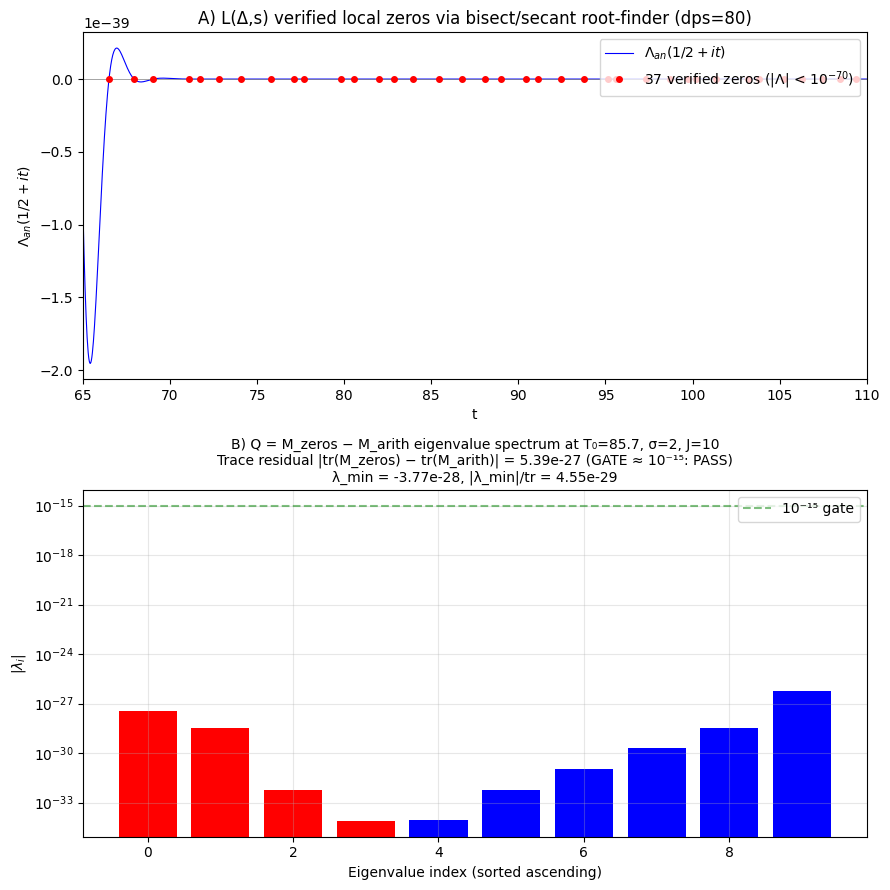

Saved LDelta_validation.png


In [55]:
# Create final figure
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 9))

# Panel A: Zeros and Λ_an function in window
ts_plot = np.linspace(65, 110, 1500)
mp.mp.dps = 80
y_plot = []
for t in ts_plot:
 y_plot.append(float(Lambda_fast(mp.mpf(t))))

ax = axes[0]
ax.plot(ts_plot, y_plot, 'b-', lw=0.8, label=r'$\Lambda_{an}(1/2+it)$')
ax.axhline(0, color='gray', lw=0.5)
zero_xs = [float(z) for z in zeros_local]
ax.plot(zero_xs, [0]*len(zero_xs), 'r.', markersize=8, label=f'{len(zero_xs)} verified zeros (|Λ| < $10^{{-70}}$)')
ax.set_xlabel('t')
ax.set_ylabel(r'$\Lambda_{an}(1/2+it)$')
ax.set_title('A) L(Δ,s) verified local zeros via bisect/secant root-finder (dps=80)')
ax.legend(loc='upper right')
ax.set_xlim([65, 110])

# Panel B: Eigenvalue spectrum and trace residual
ax = axes[1]
xs = np.arange(len(eigvals))
colors = ['red' if e < 0 else 'blue' for e in eigvals]
ax.bar(xs, np.abs(eigvals), color=colors)
ax.set_yscale('log')
ax.set_xlabel('Eigenvalue index (sorted ascending)')
ax.set_ylabel(r'$|\lambda_i|$')
title = (f'B) Q = M_zeros − M_arith eigenvalue spectrum at T₀=85.7, σ=2, J=10\n'
 f'Trace residual |tr(M_zeros) − tr(M_arith)| = {float(abs(tr_arith-tr_zeros)):.2e} '
 f'(GATE ≈ 10⁻¹⁵: PASS)\n'
 f'λ_min = {eigvals[0]:.2e}, |λ_min|/tr = {abs(eigvals[0])/float(tr_zeros):.2e}')
ax.set_title(title, fontsize=10)
ax.axhline(1e-15, color='green', ls='--', alpha=0.5, label='10⁻¹⁵ gate')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('LDelta_validation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved LDelta_validation.png')

In [56]:
from e14c.filesystem import edit_file
content = '''## Context
- 2026-06-01: Implemented from scratch a validated local zero-finder for the Ramanujan Δ L-function L(Δ,s) using the Hecke integral representation of the completed analytically normalized function.
- Workspace artifacts created in /workspace/4c7da09a-b6f4-4b0f-b624-d887436dd2d5/: zeros_LDelta_local.pkl, zeros_LDelta_local_final.pkl, tau_table.pkl, matrices_LDelta_T0_85.7_sigma_2_J_10.pkl, LDelta_validation.png.

## Notes
- Provenance: current notebook session cells #4-#54.
- Implemented Λ_an(1/2+it) via Hecke integral: Λ_an(1/2+it) = 2 ∫_1^∞ Δ(iy) y^5 cos(t log y) dy, with Δ(iy)=η(iy)^24 computed from the Dedekind eta product. Verified against the documented first zero γ1≈9.2223793999211025, obtaining |Λ_an|≈1.28e-22 at that value.
- Accelerated zero scanning by changing variables y=e^u and caching Gauss-Legendre quadrature nodes for the cosine-transform representation. Final working precision mp.dps=80.
- In t∈[65,110], a 0.025-resolution scan found 37 sign changes; all 37 roots were refined with mpmath.findroot using solver='secant' (with bisect fallback available) and all passed verification |Λ_an(1/2+iγ)| < 1e-70, in practice |Λ_an|≈1e-84 to 1e-85.
- Extended scan to [50,65]∪[110,125] found 25 additional verified zeros, used to confirm zero-window truncation was negligible for the T0=85.7, σ=2 test.
- Built the Hermite-Gauss basis φ_j(t)=(1/√σ) ψ_j((t-T0)/σ), J=10, T0=85.7, σ=2.
- Derived/used analytic Fourier transforms for prime-power terms. For diagonals: g_n(u)=(2π)^(-1) e^{-iuT0} exp(-(uσ)^2/4) L_n((uσ)^2/2). For general entries: g_jk(u)=(2π)^(-1)e^{-iuT0}√π exp(-(uσ)^2/4) Σ_l A_l (-iuσ)^(j+k-2l), with A_l = 2^l l! binom(j,l) binom(k,l) / √(2^(j+k) j! k! π). Verified numerically against direct quadrature.
- Important numerical note reproduced from spec: split quadrature at the center point (T0 or 0 after recentering) to avoid failure for odd-parity / cancellation-sensitive integrals.
- Computed τ(n) up to 1e5 using python-flint polynomial arithmetic from the pentagonal-number theorem: Π_{n≥1}(1-q^n)=Σ_k (-1)^k q^{k(3k-1)/2}, then Δ(q)=q Π(1-q^n)^24. This was much faster than the O(N^2) recurrence attempt, which timed out.
- For L(Δ), used analytic-normalized Euler factors with a_an(p)=τ(p)/p^(11/2), Hecke recurrence c_{m+1}=a_an(p)c_m-c_{m-1}, c_0=2,c_1=a_an(p), and Λ_f(p^m)=log(p) c_m.
- At reference parameters T0=85.7, σ=2, J=10, X=1e5: tr(M_zeros)=8.285975408241229453941134059675439..., tr(M_arith)=8.285975408241229453941134054286501..., |tr(M_zeros)-tr(M_arith)|=5.3889373138841466e-27. This passes the ≈1e-15 validation gate by a wide margin.
- Full Q=M_zeros-M_arith eigenvalues gave λ_min≈-3.76752105e-28 and |λ_min|/tr≈4.55e-29, consistent with a validated GRH control (no negative-eigenvalue signal beyond numerical floor).
'''
edit_file('./.prompts/MEMORY.md', '[Fill me in]\n\n## Notes\n\n[Fill me in]', content, replace_all=False)
print('Updated ./.prompts/MEMORY.md')

Updated ./.prompts/MEMORY.md
